<a href="https://colab.research.google.com/github/lucitaruizcarranza-source/Portafolio-LMRC/blob/main/Caso_Practico_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

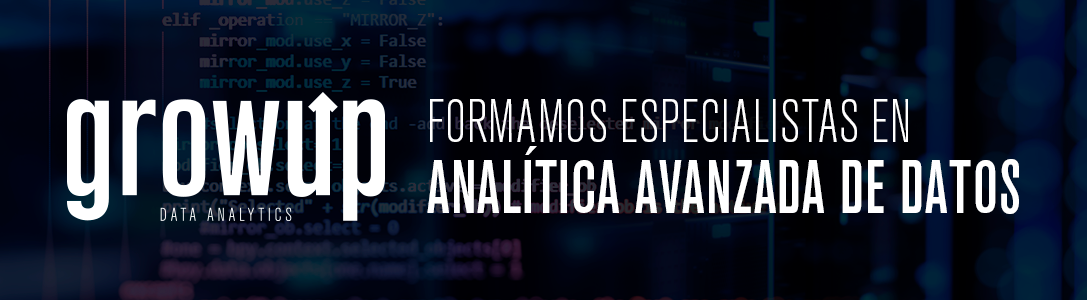

### **Proceso General del Forecast:**
* **Exploración de Datos:**
1. Se realizará un análisis exploratorio (EDA) de las ventas para identificar patrones de tendencias y estacionalidades en las series temporales.
2. Se detectarán y manejarán posibles valores atípicos o datos faltantes en la columna de ventas.
3. Las ventas se graficarán a lo largo del tiempo para observar posibles patrones de tendencia o ciclos estacionales que podrían influir en la predicción.

* **Transformación de Datos:**

Los datos de ventas se convertirán en features útiles para el modelo, tales como:
1. Lags (ventanas de tiempo).
2. Promedios móviles.
3. Agregaciones por mes o semana.
4. Características derivadas como mes, día de la semana, y festivos.
* Se garantizará que las características generadas reflejen los patrones observados en los datos históricos.


* **Selección del Modelo:**

1. Se utilizará LightGBM como el modelo principal para realizar el forecast. Este algoritmo basado en boosting es ideal para manejar series temporales con múltiples características predictivas.
2. LightGBM permitirá manejar grandes volúmenes de datos y generar predicciones precisas aprovechando las características temporales.
3. Se aplicarán técnicas de hiperparámetro tuning y validación cruzada para optimizar el rendimiento del modelo..

* **Evaluación del Modelo:**

1. Se utilizarán métricas como RMSE (Root Mean Squared Error) y MAE (Mean Absolute Error) para evaluar el rendimiento del modelo.
2. Las predicciones se compararán con los valores reales para validar el modelo y ajustarlo según sea necesario.
3. El objetivo será minimizar los errores de predicción y obtener estimaciones precisas de ventas.

* **Visualización de Resultados:**

1. Se generarán gráficos interactivos para visualizar las predicciones de ventas futuras utilizando las predicciones.
2. Se visualizarán las tendencias, estacionalidades y los valores predichos vs observados en gráficos claros para facilitar la interpretación de los resultados y apoyar la toma de decisiones basada en los datos.


# **Forecast de Ventas por País y Categoría de Tarjeta: Predicción Basada en Series Temporales**

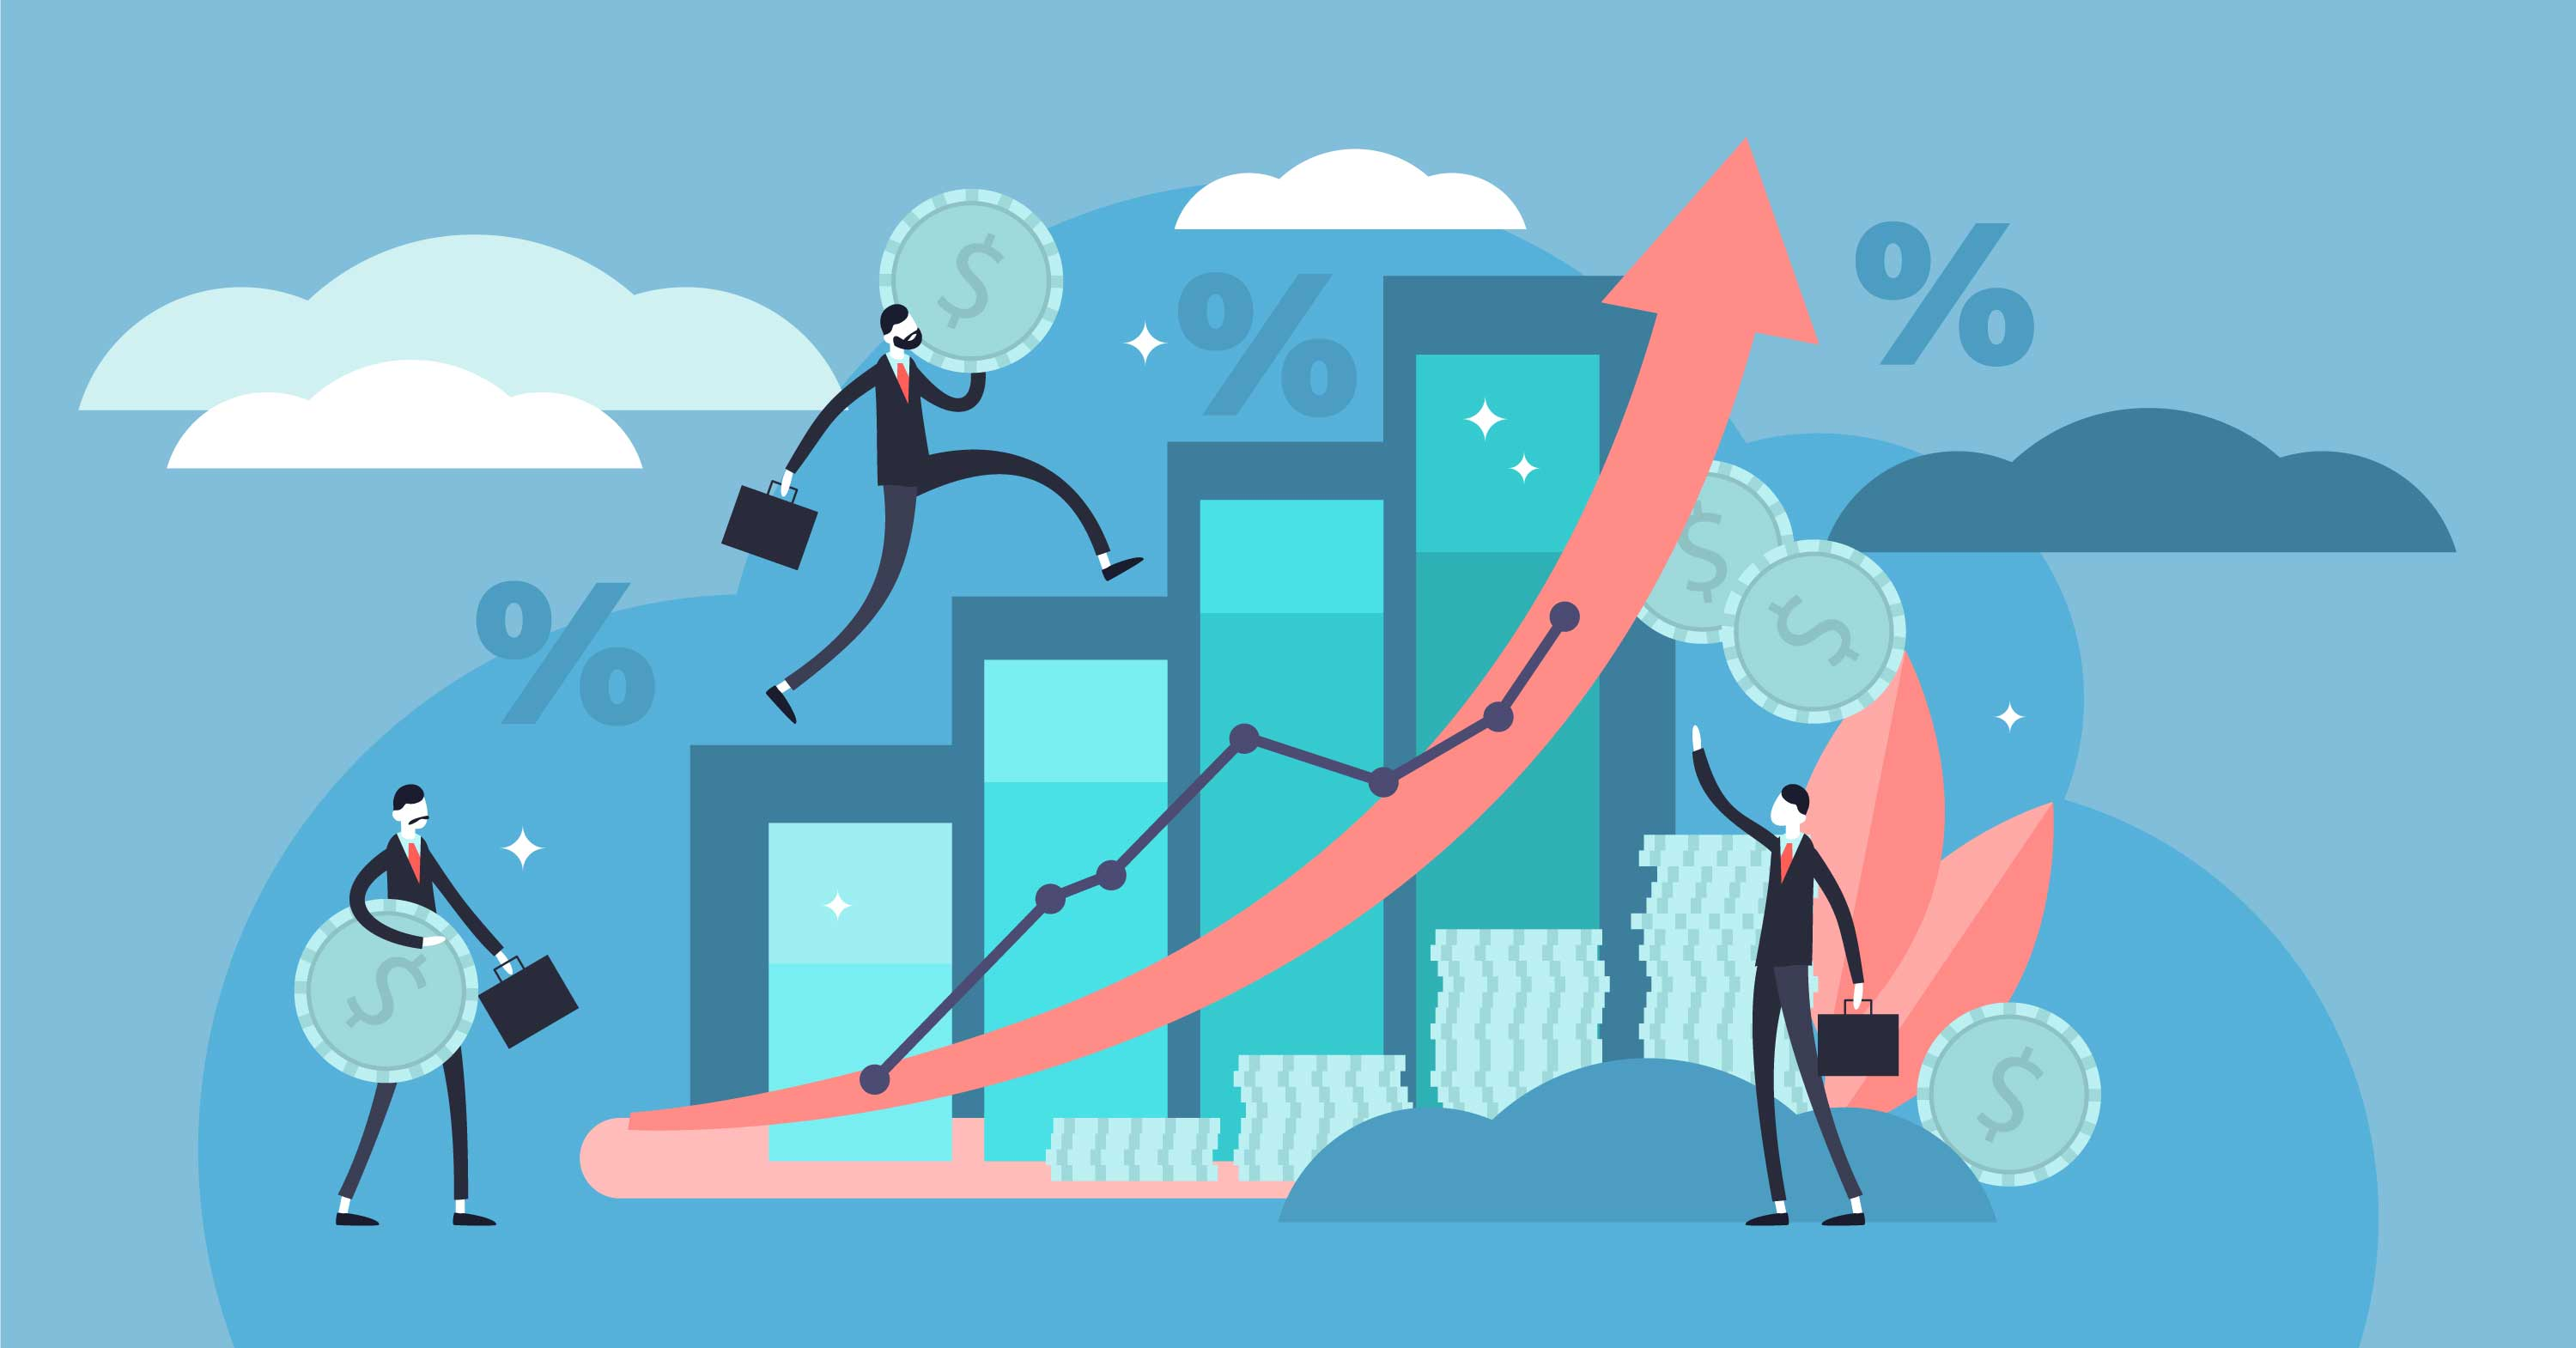

## **Definición del problema**

El forecasting (pronóstico) es una técnica de análisis predictivo que busca predecir valores futuros basándose en datos históricos. Se utiliza en una variedad de campos como finanzas, ventas, meteorología, entre otros. En este proyecto, el objetivo principal es realizar un análisis de series temporales para predecir las ventas futuras. Utilizando los datos históricos proporcionados, aplicaremos diferentes métodos de forecasting, como descomposición de series temporales, modelos de regresión y algoritmos avanzados como LightGBM. Este análisis permitirá a la empresa anticipar tendencias y ajustar sus estrategias comerciales.

**Objetivo del Proyecto:**

El objetivo del forecast es predecir el comportamiento de las ventas en el futuro, utilizando como base la información de fecha del pedido, categoría de tarjeta, país, y ventas. Esto permitirá obtener información sobre posibles incrementos o descensos en las ventas en distintos periodos, lo que permitirá a la empresa tomar decisiones estratégicas basadas en datos.

**Descripción del Dataset:**

El dataset que vamos a utilizar contiene información detallada de las ventas por fecha, categorizadas por tarjeta y país. A continuación, se presenta una descripción de las principales columnas:

* **Fecha Pedido:** Indica el día en que se realizó el pedido. Esta será la variable temporal clave para el análisis de forecasting.
* **Categoría Tarjeta:** Tipo de tarjeta utilizada para la compra, con valores como 'Azul', 'Oro', 'Plata', entre otros.
* **País:** País en el que se realizó la venta. Esto permitirá analizar las ventas por región geográfica.
* **Ventas:** Monto total de ventas realizadas en un día específico.
Cada fila del dataset representa una combinación única de fecha, categoría de tarjeta, y país, junto con el total de ventas para esa combinación en ese día.

# 📥 **Importar Librerías**

In [1]:
## Base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import statsmodels
import plotly.graph_objs as go
from plotly.subplots import make_subplots

## Visualizacion Interactiva
import bokeh
from bokeh.models import CustomJS, ColumnDataSource, Slider, Label, Div, HoverTool, Band, Span, Select, BoxAnnotation
from bokeh.plotting import figure, show, ColumnDataSource
from bokeh.palettes import Spectral11
from bokeh.layouts import column, row
from bokeh.io import curdoc
import ipywidgets as widgets
bokeh.io.output_notebook()


#Modelos
import lightgbm as lgb
#!pip install shap
#import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer


## Configuracion de errores
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# ✅ **Cargar el Conjunto de Datos**

In [ ]:
url_train = "https://raw.githubusercontent.com/emadrigals104/PLFPython/main/Datasets/df_train.csv"

df = pd.read_csv(url_train,
                 sep=',',header=0,parse_dates=['Fecha Pedido'])

# **Exploración de datos**
La exploración de datos es el primer paso en cualquier proyecto de ciencia de datos. Consiste en revisar y entender el conjunto de datos, observando su tamaño, la naturaleza de las variables, y buscando posibles valores faltantes o inconsistencias. Esta etapa ayuda a obtener una visión general antes de comenzar con análisis más complejos. Algunos de los aspectos clave incluyen:

* **Distribución de las variables:** Examinar si las variables siguen una distribución normal o no.
* **Tipos de datos:** Identificar si los datos son categóricos, numéricos o de otro tipo.
* **Valores faltantes:** Revisar si hay valores nulos que deban tratarse.

In [ ]:
df.head()

,Fecha Pedido,Categoría Tarjeta,País,Ventas,ID Cliente,Nombre Cliente
0,2019-01-01,Azul,Ecuador,13,GM-14440,Gary McGarr
1,2019-01-02,Azul,Ecuador,11,RD-19720,Roger Demir
2,2019-01-03,Azul,Ecuador,14,DK-12835,Damala Kotsonis
3,2019-01-04,Azul,Ecuador,13,JF-15295,Jason Fortune-
4,2019-01-05,Azul,Ecuador,10,ML-17755,Max Ludwig


In [ ]:
df.tail()

,Fecha Pedido,Categoría Tarjeta,País,Ventas,ID Cliente,Nombre Cliente
72995,2023-12-27,Platino,Perú,57,DS-13030,Darrin Sayre
72996,2023-12-28,Platino,Perú,53,DP-13105,Dave Poirier
72997,2023-12-29,Platino,Perú,65,ZD-21925,Zuschuss Donatelli
72998,2023-12-30,Platino,Perú,74,AA-10480,Andrew Allen
72999,2023-12-31,Platino,Perú,69,MV-18190,Mike Vittorini


In [ ]:
df.shape

(73000, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73000 entries, 0 to 72999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Fecha Pedido       73000 non-null  datetime64[ns]
 1   Categoría Tarjeta  73000 non-null  object        
 2   País               73000 non-null  object        
 3   Ventas             73000 non-null  int64         
 4   ID Cliente         73000 non-null  object        
 5   Nombre Cliente     73000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 3.3+ MB


In [ ]:
df.describe()

,Fecha Pedido,Ventas
count,73000,73000.000000
mean,2021-07-01 18:25:26.794520576,52.141836
min,2019-01-01 00:00:00,3.000000
25%,2020-04-02 00:00:00,28.000000
50%,2021-07-02 00:00:00,49.000000
75%,2022-10-01 00:00:00,71.000000
max,2023-12-31 00:00:00,181.000000
std,NaN,28.305767


In [ ]:
df.isnull().sum()

,0
Fecha Pedido,0
Categoría Tarjeta,0
País,0
Ventas,0
ID Cliente,0
Nombre Cliente,0


# **5 Preguntas que todo Cientifico de Datos debe responder en un Forecast**

## **1. ¿Cómo están distribuidos los datos y qué patrones iniciales podemos observar?**
 **Propósito:** Obtener una comprensión general de los datos, detectar patrones y posibles problemas desde el principio.

* **Preguntas relacionadas:**

1. ¿Qué tendencias se observan en las ventas por categoría de tarjeta y país?
2. ¿Existen valores atípicos que deban ser tratados antes del modelado?
3. ¿Qué patrones temporales podemos identificar a través de la descomposición de la serie temporal?
* **Acciones en el EDA:**
1. Revisar la metadata de los datos y generar gráficos de barras para analizar la distribución de las ventas.
2. Descomponer la serie temporal para identificar tendencia, estacionalidad y ruido.
3. Detectar y tratar valores atípicos en los datos de ventas para evitar sesgos en el modelo.

# **Análisis Exploratorio de Datos**
El Análisis Exploratorio de Datos (EDA) es una fase crítica para identificar patrones, relaciones entre variables y posibles outliers. A través de gráficos (histogramas, scatter plots, box plots) y estadísticas descriptivas, se busca profundizar en el entendimiento de los datos. Los objetivos del EDA son:

* **Identificar relaciones:** Evaluar cómo se relacionan las diferentes variables entre sí.
* **Detectar patrones:** Observar tendencias que podrían ser útiles para el modelado.
* **Outliers o valores atípicos:** Detectar datos que no siguen el comportamiento general del conjunto, que podrían afectar los resultados.

In [ ]:
valores_unicos = df.nunique()
pd.DataFrame(valores_unicos, columns=["Valores Únicos"]).transpose()

,Fecha Pedido,Categoría Tarjeta,País,Ventas,ID Cliente,Nombre Cliente
Valores Únicos,1825,4,10,175,637,637


Podemos observar que la columna ID fila puede no ser útil ya que todos los valores son identificadores únicos, por lo que podemos descartarla.

In [ ]:
df = df.drop(columns=['ID Cliente', 'Nombre Cliente'])

df.head()

,Fecha Pedido,Categoría Tarjeta,País,Ventas
0,2019-01-01,Azul,Ecuador,13
1,2019-01-02,Azul,Ecuador,11
2,2019-01-03,Azul,Ecuador,14
3,2019-01-04,Azul,Ecuador,13
4,2019-01-05,Azul,Ecuador,10


### **Revisamos la Metadata de la informacion que trabajaremos**

In [ ]:
print(f'Datos: {len(df)}')

Datos: 73000


In [ ]:
# Ordenamos los valores únicos de la columna 'País'
pais = sorted(df['País'].unique())
print(f'País: {pais}')

País: ['Argentina', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Estados Unidos', 'Guatemala', 'Perú', 'Uruguay']


In [ ]:
# Ordenamos los valores únicos de la columna 'Categoría Tarjeta'
tarjeta = sorted(df['Categoría Tarjeta'].unique())
print(f'Categoría Tarjeta: {tarjeta}')

Categoría Tarjeta: ['Azul', 'Oro', 'Plata', 'Platino']


In [ ]:
# Convertimos las fechas a formato de fecha y ordenamos
fecha = df['Fecha Pedido'].sort_values().unique()
print(f'Dates (Train / Test) : {fecha[0]} - {fecha[-1]}')

Dates (Train / Test) : 2019-01-01 00:00:00 - 2023-12-31 00:00:00


In [ ]:
import plotly.express as px

# 1. Agrupar los datos por 'Categoría Tarjeta' y sumar las 'Ventas', luego ordenar de mayor a menor
df_ventas_categoria = df.groupby('Categoría Tarjeta')['Ventas'].sum().reset_index()
df_ventas_categoria = df_ventas_categoria.sort_values(by='Ventas', ascending=False)

# 2. Crear el gráfico de barras utilizando Plotly Express con degradado de color
fig = px.bar(
    df_ventas_categoria,
    x='Categoría Tarjeta',
    y='Ventas',
    title='Ventas por Categoría Tarjeta',
    labels={'Ventas': 'Total Ventas', 'Categoría Tarjeta': 'Categoría Tarjeta'},
    text='Ventas',
    color='Ventas',  # Aplicar un degradado de color basado en el valor de ventas
    color_continuous_scale='Blues'  # Escala de color en degradado (puedes cambiarla)
)

# 3. Personalizar el gráfico (formato de número y eliminar el fondo azul)
fig.update_traces(
    texttemplate='%{text:,.0f}',  # Aplicar formato de número con separador de miles
    textposition='outside'
)

# 4. Quitar el fondo de las barras y la barra lateral de color
fig.update_layout(
    plot_bgcolor='white',  # Fondo blanco
    uniformtext_minsize=8,
    uniformtext_mode='hide',
    xaxis_tickangle=-45,
    coloraxis_showscale=False  # Esta línea quita la barra lateral de color
)

# 5. Mostrar el gráfico
fig.show()

In [ ]:
import plotly.express as px

# 1. Agrupar los datos por 'País' y sumar las 'Ventas', luego ordenar de mayor a menor
df_ventas_pais = df.groupby('País')['Ventas'].sum().reset_index()
df_ventas_pais = df_ventas_pais.sort_values(by='Ventas', ascending=False)

# 2. Crear el gráfico de barras utilizando Plotly Express con degradado de color
fig = px.bar(
    df_ventas_pais,
    x='País',
    y='Ventas',
    title='Ventas por País',
    labels={'Ventas': 'Total Ventas', 'País': 'País'},
    text='Ventas',
    color='Ventas',  # Aplicar un degradado de color basado en el valor de ventas
    color_continuous_scale='Blues'  # Escala de color en degradado (puedes cambiarla)
)

# 3. Personalizar el gráfico (formato de número y eliminar el fondo azul)
fig.update_traces(
    texttemplate='%{text:,.0f}',  # Aplicar formato de número con separador de miles
    textposition='outside'
)

# 4. Quitar el fondo de las barras y la barra lateral de color
fig.update_layout(
    plot_bgcolor='white',  # Fondo blanco
    uniformtext_minsize=8,
    uniformtext_mode='hide',
    xaxis_tickangle=-45,
    coloraxis_showscale=False  # Quitar la barra lateral de color
)

# 5. Mostrar el gráfico
fig.show()


### **Grafica Interactiva Comparativa Pais y Tipo Tarjeta**

In [ ]:
# Convertir las columnas a cadenas y crear la columna combinada 'Pais-Tarjeta'
df['País'] = df['País'].astype(str)
df['Categoría Tarjeta'] = df['Categoría Tarjeta'].astype(str)
df['Pais-Tarjeta'] = df['País'] + '_' + df['Categoría Tarjeta']

# Pivotear los datos y hacer resample para obtener la media semanal
ventas = df.pivot_table(index='Fecha Pedido', columns='Pais-Tarjeta', values='Ventas', aggfunc='mean').resample('W').mean()
df.drop(columns=['Pais-Tarjeta'], inplace=True)

# Resetear el índice para que 'Fecha Pedido' sea una columna
ventas = ventas.reset_index()

# Obtener listas únicas de países y categorías de tarjetas
paises = df['País'].unique().tolist()
categorias_tarjeta = df['Categoría Tarjeta'].unique().tolist()

# Selecciones iniciales
pais = paises[0]
categoria = categorias_tarjeta[0]

i = pais + '_' + categoria

# Preparar la fuente de datos
fuente_ventas = pd.DataFrame({
    'Fecha Pedido': ventas['Fecha Pedido'],
    'y': ventas[i].values if i in ventas.columns else [0]*len(ventas)
})
source = ColumnDataSource(data=fuente_ventas)

# Preparar la fuente de datos de referencia
datos_ref = ventas.copy()
ref = ColumnDataSource(data=datos_ref)

# Crear la figura
p = figure(width=750, height=300, title=i, x_axis_type='datetime', tools="pan,wheel_zoom,reset")
linea = p.line(x='Fecha Pedido', y='y', source=source, color='blue', legend_label='Ventas')

# Añadir tooltips
tooltips = [
    ('Fecha Pedido', '@{Fecha Pedido}{%F}'),
    ('Ventas', '@y'),
]

hover = HoverTool(
    tooltips=tooltips,
    formatters={'@{Fecha Pedido}': 'datetime'},
    mode='vline',
    renderers=[linea]
)
p.add_tools(hover)

# Crear widgets de selección
select_pais = Select(title="País", value=pais, options=paises)
select_categoria = Select(title="Categoría Tarjeta", value=categoria, options=categorias_tarjeta)

# Definir la callback
callback = CustomJS(
    args=dict(source=source, ref=ref, country_select=select_pais, category_select=select_categoria, p=p),
    code="""
    var pais = country_select.value;
    var categoria = category_select.value;
    var nombre_columna = pais + '_' + categoria;

    var datos = ref.data;
    var y_nueva = datos[nombre_columna];
    if (y_nueva === undefined) {
        y_nueva = Array(source.data['y'].length).fill(0);
    }

    source.data['y'] = y_nueva;
    p.title.text = nombre_columna;
    source.change.emit();
"""
)

# Conectar las callbacks a los widgets
select_pais.js_on_change('value', callback)
select_categoria.js_on_change('value', callback)

# Organizar el layout
layout = column(
    Div(text='<h4>Reporte de Ventas (Bokeh)</h4>'),
    row(select_pais, select_categoria),
    p
)

show(layout)


## **Descomposicion Serie Temporal**
En proyectos de predicción basados en datos temporales, es crucial descomponer la serie en sus componentes principales para entender mejor el comportamiento subyacente. Estos componentes suelen ser:

* **Tendencia:** Representa la dirección a largo plazo de la serie temporal.
* **Estacionalidad:** Componente repetitivo que ocurre en intervalos regulares (como ciclos mensuales o anuales).
* **Ruido:** Variaciones aleatorias que no siguen un patrón específico.

In [14]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf
import statsmodels.stats.diagnostic
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import numpy as np # Ensure numpy is available for feature creation
from sklearn.preprocessing import LabelEncoder # Ensure LabelEncoder is available

# --- Re-initializing df for this cell to run in isolation ---
# This section replicates essential data loading and preprocessing steps from previous cells

# 1. Load df_train (from cell pdQhiWeUlSBH)
url_train = "https://raw.githubusercontent.com/emadrigals104/PLFPython/main/Datasets/df_train.csv"
df = pd.read_csv(url_train, sep=',',header=0,parse_dates=['Fecha Pedido'])

# 2. Drop columns (from cell 6lKkJA9Opad1)
df = df.drop(columns=['ID Cliente', 'Nombre Cliente'])

# 3. Load df_test (from cell ypTgLEEUM-ap)
url_test = "https://raw.githubusercontent.com/emadrigals104/PLFPython/main/Datasets/df_test.csv"
df_test = pd.read_csv(url_test, sep=',',header=0,parse_dates=['Fecha Pedido'])

# 4. Concatenate df and df_test (from cell kxExR5XsNfzy)
df = pd.concat([df, df_test], sort=False)

# 5. Define create_date_features function and apply it (from cell 012LTrFEA8Dq)
def create_date_features(df):
    df['nro_mes'] = df['Fecha Pedido'].dt.month
    df['dia_mes'] = df['Fecha Pedido'].dt.day
    df['dia_anio'] = df['Fecha Pedido'].dt.dayofyear
    df['semana_anio'] = df['Fecha Pedido'].dt.isocalendar().week
    df['dia_semana'] = df['Fecha Pedido'].dt.dayofweek + 1
    df['anio'] = df['Fecha Pedido'].dt.year
    df["fin_semana"] = df['Fecha Pedido'].dt.weekday // 4
    df["trimestre"] = df['Fecha Pedido'].dt.quarter
    df['inicio_mes'] = df['Fecha Pedido'].dt.is_month_start.astype(int)
    df['fin_mes'] = df['Fecha Pedido'].dt.is_month_end.astype(int)
    df['inicio_trim'] = df['Fecha Pedido'].dt.is_quarter_start.astype(int)
    df['fin_trim'] = df['Fecha Pedido'].dt.is_quarter_end.astype(int)
    df['inicio_anio'] = df['Fecha Pedido'].dt.is_year_start.astype(int)
    df['fin_anio'] = df['Fecha Pedido'].dt.is_year_end.astype(int)
    # 1: Invierno - 2: Verano (keeping original logic)
    df["estacion"] = np.where(df.nro_mes.isin([12,1,2,3,4]), 2, 1)
    return df
df = create_date_features(df)

# 6. Label encode (from cell YpUczfHqmOIA)
# Define label encoders as global to be accessible for inverse_transform later if needed
global label_encoder_pais, label_encoder_categoria
label_encoder_pais = LabelEncoder()
label_encoder_categoria = LabelEncoder()

# Ensure columns are string type before encoding to avoid mixed type errors
df['País'] = df['País'].astype(str)
df['Categoría Tarjeta'] = df['Categoría Tarjeta'].astype(str)

df['País'] = label_encoder_pais.fit_transform(df['País']) + 1
df['Categoría Tarjeta'] = label_encoder_categoria.fit_transform(df['Categoría Tarjeta']) + 1

# --- End of df re-initialization ---

# Mapeo de frecuencias para la estacionalidad
freq_season_mapping = {'Ninguna': None, 'Semanal': 7, 'Mensual': 30, 'Anual': 365}

def descomposicion_stl(categoria, pais, estacionalidad='Anual', tipo_stl='additive'):
    # Filtrar los datos según el país y la categoría de tarjeta seleccionados
    ts = df[(df['País'] == pais) & (df['Categoría Tarjeta'] == categoria)].set_index('Fecha Pedido')['Ventas']
    ts = ts.asfreq('D').fillna(0)
    freq = freq_season_mapping[estacionalidad]

    if ts.empty:
        print("No hay datos disponibles para esta combinación de país y categoría de tarjeta.")
        return

    try:
        # Realizar la descomposición STL
        descomposicion = sm.tsa.seasonal_decompose(ts, model=tipo_stl, period=freq)

        # Crear la figura y los ejes
        fig, ax = plt.subplots(5, 1, figsize=(12, 10))
        descomposicion.observed.plot(ax=ax[0], title='Observada')
        descomposicion.trend.plot(ax=ax[1], title='Tendencia')
        descomposicion.seasonal.plot(ax=ax[2], title='Estacionalidad')
        descomposicion.resid.plot(ax=ax[3], title='Residuo')

        # Análisis de los residuales y prueba de Ljung-Box
        res = descomposicion.resid.dropna().values
        if len(res) == 0:
            print("No hay suficientes datos residuales para calcular PACF y prueba de Ljung-Box.")
            plt.show()
            return

        ljungbox_stat = sm.stats.diagnostic.acorr_ljungbox(res, lags=[6, 10])

        # Acceder a los p-valores correctamente usando .iloc[]
        pvalue_6 = ljungbox_stat['lb_pvalue'].iloc[0]
        pvalue_10 = ljungbox_stat['lb_pvalue'].iloc[1]

        # Gráfico PACF de los residuales
        plot_pacf(res, ax=ax[4], lags=40,
                  title='PACF de residuales; p-valor de Ljung-Box = {:.2E} / {:.2E}'.format(
                      pvalue_6, pvalue_10))
        fig.suptitle('Descomposición STL')
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    except ValueError as e:
        print("Error en la descomposición STL:", e)
        return

# Obtener listas únicas de países y categorías de tarjetas
paises = df['País'].astype(str).unique().tolist()
categorias_tarjeta = df['Categoría Tarjeta'].astype(str).unique().tolist()

# Definir widgets
widget_pais = widgets.Dropdown(options=paises, description='País', layout={'width': '2.1in'})
widget_categoria = widgets.Dropdown(options=categorias_tarjeta, description='Categoría Tarjeta', layout={'width': '2.1in'})
widget_estacionalidad = widgets.Dropdown(value='Anual', options=['Ninguna', 'Semanal', 'Mensual', 'Anual'], description='Estacionalidad', layout={'width': '2.1in'})
widget_tipo_stl = widgets.Dropdown(value='additive', options=['additive', 'multiplicative'], description='Tipo STL', layout={'width': '2.1in'})

# Crear interfaz interactiva
ui = widgets.HBox([widget_pais, widget_categoria, widget_estacionalidad, widget_tipo_stl], layout={'min_width': '6in', 'max_width': '20in'})
out = widgets.interactive_output(descomposicion_stl, {
    'pais': widget_pais,
    'categoria': widget_categoria,
    'estacionalidad': widget_estacionalidad,
    'tipo_stl': widget_tipo_stl
})

# Mostrar interfaz
display(ui, out)

Output()

### **Valores Atípicos**
Los valores atípicos son observaciones que se desvían significativamente del resto de los datos. Pueden ser el resultado de errores en la recolección de datos o eventos raros. La detección y tratamiento adecuado de estos valores es fundamental, ya que pueden distorsionar el análisis y los modelos predictivos.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


              ds      y       yhat  yhat_lower  yhat_upper  anomaly
10187 2021-11-29  112.0  45.553929  -15.330750  104.854406     True
10752 2023-06-17  150.0  74.874700   12.308853  141.471063     True
10793 2023-07-28  135.0  73.214178    6.320559  131.085440     True
30442 2022-05-28   10.0  70.775717   10.075720  134.657511     True
38897 2020-07-27  126.0  60.107913    0.932560  125.293741     True
...          ...    ...        ...         ...         ...      ...
71142 2023-11-29  113.0  50.678821  -18.619069  111.434950     True
72020 2021-04-26  118.0  54.495519  -20.676005  116.499046     True
72111 2021-07-26  127.0  63.009117   -3.175402  123.543829     True
72237 2021-11-29  106.0  45.553929  -15.330750  104.854406     True
72824 2023-07-09  154.0  81.814437   19.201494  141.098597     True

[586 rows x 6 columns]


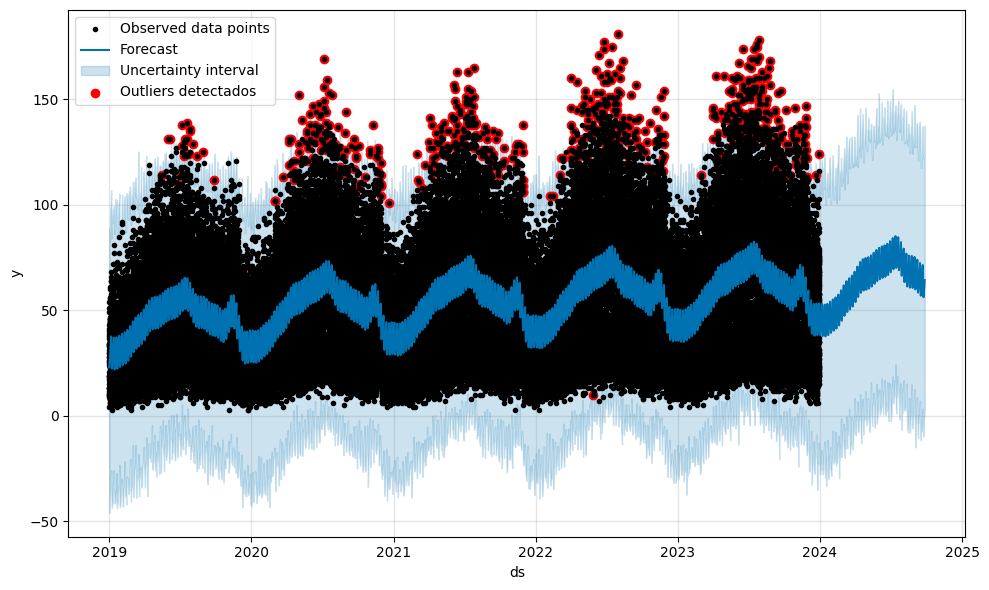

In [17]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparamos los datos para Prophet
df_prophet = df[['Fecha Pedido', 'Ventas']].rename(columns={'Fecha Pedido': 'ds', 'Ventas': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# 2. Inicializamos el modelo Prophet
model = Prophet(interval_width=0.99)  # Ajustar el intervalo de confianza al 95%

# 3. Ajustamos el modelo con los datos
model.fit(df_prophet)

# 4. Generamos fechas futuras para el pronóstico (180 días hacia adelante)
future = model.make_future_dataframe(periods=180, freq='D')

# 5. Realizamos el pronóstico
forecast = model.predict(future)

# 6. Alineamos las predicciones con los datos históricos
# Nos quedamos solo con las predicciones correspondientes a las fechas históricas
forecast_historical = forecast[forecast['ds'] <= df_prophet['ds'].max()]

# 7. Volvemos a unir las predicciones con los valores reales de ventas
df_merged = pd.merge(df_prophet, forecast_historical[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

# 8. Identificamos outliers
df_merged['anomaly'] = (df_merged['y'] > df_merged['yhat_upper']) | (df_merged['y'] < df_merged['yhat_lower'])

# 9. Extraemos los outliers
outliers = df_merged[df_merged['anomaly'] == True]

# 10. Imprimimos los outliers detectados
print(outliers)

# 11. Visualizamos el pronóstico y los outliers
fig = model.plot(forecast)
plt.scatter(outliers['ds'], outliers['y'], color='red', label='Outliers detectados')
plt.legend()
plt.show()


In [18]:
# Contamos el número de outliers en el DataFrame
num_outliers = df_merged['anomaly'].sum()

# Imprimimos el número total de outliers
print(f"Número total de outliers detectados: {num_outliers}")


Número total de outliers detectados: 586


In [19]:
df_merged.loc[df_merged['anomaly'], 'y'] = df_merged.loc[df_merged['anomaly'], 'yhat']

## **2. ¿Cómo se relacionan las diferentes variables entre sí y con la variable objetivo (ventas)?**
**Propósito:** Evaluar las correlaciones y relaciones entre las variables que puedan influir en la predicción.
* **Preguntas relacionadas:**
1. ¿Existen correlaciones fuertes entre las variables categóricas, numéricas y la variable objetivo (ventas)?
2. ¿Qué conclusiones se pueden extraer de la prueba de hipótesis en las variables clave?
3. ¿Cómo impactan transformaciones básicas como Label Encoding y variables derivadas de la fecha en las ventas?
* **Acciones en el EDA:**
1. Aplicar transformaciones básicas como Label Encoding y la creación de nuevas features derivadas de la fecha.
2. Realizar una prueba de hipótesis para verificar si ciertas variables tienen un impacto significativo en las ventas.
3. Aplicar transformaciones en los datos como Lag/Shifted Features y Rolling Mean para enriquecer las características y observar su impacto en la correlación.

## **Correlacion Entre Variables**
La correlación es una medida estadística que describe la relación entre dos variables. En el análisis de datos, es útil identificar correlaciones fuertes entre variables porque pueden ayudar a explicar el comportamiento de la variable objetivo. Es importante distinguir entre correlación y causalidad: una correlación alta no implica necesariamente que una variable cause cambios en la otra.

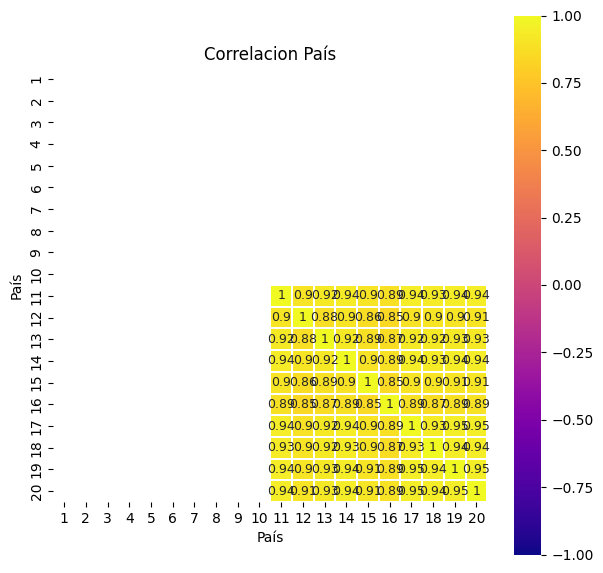

In [22]:
pais_ventas = df.groupby(['Fecha Pedido', 'País']).Ventas.sum().reset_index().set_index('Fecha Pedido')
categoria_ventas = df.groupby(['Fecha Pedido', 'Categoría Tarjeta']).Ventas.sum().reset_index().set_index('Fecha Pedido')

corr =  pd.pivot_table(pais_ventas, values = 'Ventas', columns='País', index='Fecha Pedido').corr(method = "spearman")

plt.figure(figsize = (7,7))
plt.title('Correlacion País' )
sns.heatmap(corr,
            cmap='plasma', vmax=1.0, vmin=-1.0, linewidths=0.1,
            annot=True, annot_kws={"size": 9}, square=True);

In [23]:
df_test

,id,Fecha Pedido,Categoría Tarjeta,País
0,0,2024-01-01,1,1
1,1,2024-01-02,1,1
2,2,2024-01-03,1,1
3,3,2024-01-04,1,1
4,4,2024-01-05,1,1
...,...,...,...,...
3595,8455,2024-03-27,4,10
3596,8456,2024-03-28,4,10
3597,8457,2024-03-29,4,10
3598,8458,2024-03-30,4,10


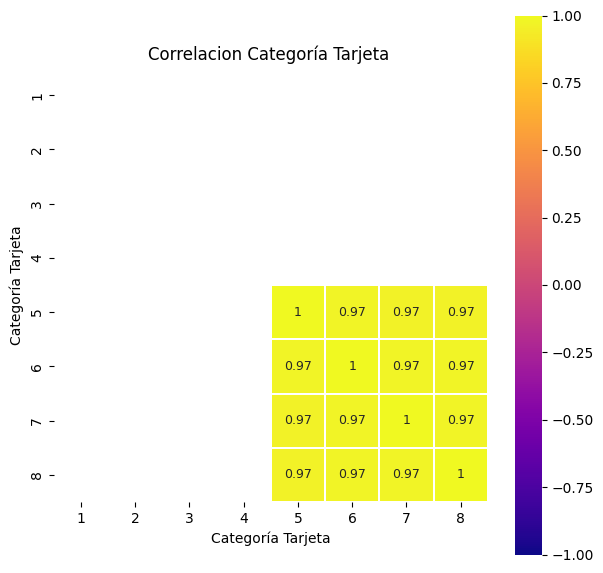

In [24]:
corr =  pd.pivot_table(categoria_ventas, values = 'Ventas', columns='Categoría Tarjeta', index='Fecha Pedido').corr(method = "spearman")

plt.figure(figsize = (7,7))
plt.title('Correlacion Categoría Tarjeta ' )
sns.heatmap(corr,
            cmap='plasma', vmax=1.0, vmin=-1.0, linewidths=0.1,
            annot=True, annot_kws={"size": 9}, square=True);

# **Prueba de Hipótesis**
La prueba de hipótesis nos permite validar o refutar suposiciones sobre las diferencias entre grupos, como categorías de tarjetas o países, y su impacto en las ventas. Nos ayuda a identificar si las diferencias observadas en las ventas entre estos grupos son significativas o pueden atribuirse al azar.

* **Flujo del Proceso:**
1. **Comparación de Grupos:** Se comparan grupos (por ejemplo, categorías de tarjetas) para verificar si hay diferencias significativas en sus ventas.

2. **Test de Normalidad (Shapiro-Wilk):** Determina si los datos de los grupos siguen una distribución normal. Dependiendo de los resultados, se elige entre una prueba paramétrica o no paramétrica.

3. **Test de Homogeneidad (Levene):** Evalúa si las varianzas de los grupos son homogéneas. Si lo son, se usa una prueba t con varianzas iguales, de lo contrario, se aplica una prueba t con varianzas desiguales.

4. **Pruebas Paramétricas o No Paramétricas:**

* **Prueba t de Student:** Para datos normales con varianzas homogéneas.
* **Prueba de Mann-Whitney U:** Para datos no normales o con varianzas heterogéneas.
5. **Conclusión:** Si el p-valor es menor a 0.05, las diferencias observadas entre los grupos son estadísticamente significativas.

In [75]:
import itertools
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind # Explicitly import ttest_ind
import pandas as pd
import numpy as np

def Comparar_dos_grupos(dataframe, grupo, objetivo):
  # Get unique categories and generate all unique pairs for comparison
  unique_groups = dataframe[grupo].unique()
  item_comb = list(itertools.combinations(unique_groups, 2))

  AB = pd.DataFrame()

  for i in range(len(item_comb)):
    group_name_A = item_comb[i][0]
    group_name_B = item_comb[i][1]

    grupoA_data = dataframe[dataframe[grupo] == group_name_A][objetivo].dropna()
    grupoB_data = dataframe[dataframe[grupo] == group_name_B][objetivo].dropna()

    # Initialize variables for the current comparison
    ttest_val = np.nan
    comparacion = 'N/A'
    tipo_prueba = 'N/A'
    mean_A = grupoA_data.mean()
    mean_B = grupoB_data.mean()
    median_A = grupoA_data.median()
    median_B = grupoB_data.median()
    count_A = grupoA_data.count()
    count_B = grupoB_data.count()

    # --- Handle cases with insufficient or constant data ---
    if grupoA_data.empty or grupoB_data.empty:
        comparacion = 'No hay datos suficientes'
    elif count_A < 3 or count_B < 3: # Shapiro test minimum requirement is 3 observations
        comparacion = 'Datos insuficientes para tests estadísticos'
    elif grupoA_data.nunique() == 1 and grupoB_data.nunique() == 1:
        # Both groups are constant
        if grupoA_data.iloc[0] == grupoB_data.iloc[0]:
            comparacion = 'Grupos Similares (valores constantes e iguales)'
            ttest_val = 1.0 # P-value 1.0 if they are identical
        else:
            comparacion = 'Grupos Diferentes (valores constantes y distintos)'
            ttest_val = 0.0 # P-value 0.0 if they are distinct constants
        tipo_prueba = 'Directa'
    elif grupoA_data.nunique() == 1 or grupoB_data.nunique() == 1:
        # One group is constant, the other is not. Assume non-normal if one is constant.
        # Proceed with non-parametric test. If it still fails, it will be NaN.
        try:
            ttest_val = mannwhitneyu(grupoA_data, grupoB_data)[1]
            comparacion = 'Grupos Diferentes' if ttest_val < 0.05 else 'Grupo Similares'
        except ValueError: # Catch if mannwhitneyu still fails (e.g., all zeros in both)
            comparacion = 'Test no aplicable (datos constantes/sin varianza)'
            ttest_val = np.nan
        tipo_prueba = 'No Parametrico'
    else:
        # --- Proceed with Shapiro and Levene tests for non-constant, sufficient data ---
        try:
            ntA = shapiro(grupoA_data)[1] < 0.05
            ntB = shapiro(grupoB_data)[1] < 0.05
        except Exception: # Catch any error during shapiro test (e.g., all identical values if not caught above)
            ntA, ntB = True, True # Assume non-normal if test fails

        if (ntA == False) & (ntB == False): # Both groups are normal (or assumed normal)
            try:
                leveneTest = levene(grupoA_data, grupoB_data)[1] < 0.05
            except Exception: # Catch any error during levene test
                leveneTest = True # Assume heterogeneous if test fails

            if leveneTest == False: # Homogeneity of variances
                try:
                    ttest_val = ttest_ind(grupoA_data, grupoB_data, equal_var=True)[1]
                except ValueError:
                    ttest_val = np.nan
            else: # Heterogeneity of variances
                try:
                    ttest_val = ttest_ind(grupoA_data, grupoB_data, equal_var=False)[1]
                except ValueError:
                    ttest_val = np.nan
            tipo_prueba = 'Parametrico'
        else: # One or both groups are not normal, or Shapiro failed
            try:
                ttest_val = mannwhitneyu(grupoA_data, grupoB_data)[1]
            except ValueError: # Catch if mannwhitneyu still fails
                ttest_val = np.nan
            tipo_prueba = 'No Parametrico'

        if comparacion == 'N/A': # Only update if not already set by earlier conditions
            comparacion = 'Grupos Diferentes' if (ttest_val is not np.nan and ttest_val < 0.05) else 'Grupo Similares'

    temp = pd.DataFrame({'Comparacion 2 Grupos':[comparacion],
                         'p-value':[ttest_val],
                         'Media_GrupoA':[mean_A],'Media_GrupoB':[mean_B],
                         'Mediana_GrupoA':[median_A], 'Mediana_GrupoB':[median_B],
                         'Cantidad_GrupoA':[count_A],'Cantidad_GrupoB':[count_B],
                         },index = [item_comb[i]])
    temp['Tipo Prueba'] = tipo_prueba

    AB = pd.concat([AB, temp[['Tipo Prueba','Comparacion 2 Grupos','p-value',
                              'Mediana_GrupoA','Mediana_GrupoB','Media_GrupoA','Media_GrupoB',
                              'Cantidad_GrupoA','Cantidad_GrupoB']]])
  return AB


#Comparar_dos_grupos(pais_ventas, grupo='País',objetivo='Ventas')

# Ensure 'Categoría Tarjeta' column in categoria_ventas is renamed to 'Categoría_Tarjeta'
# to match the consistent naming convention with underscores.
categoria_ventas.columns = categoria_ventas.columns.str.replace(' ', '_', regex=False)

item_similares = Comparar_dos_grupos(categoria_ventas,grupo='Categoría_Tarjeta',objetivo='Ventas') # Use Categoría_Tarjeta

#item_similares[item_similares['Comparacion 2 Grupos']=='Grupo Similares']
item_similares

,Tipo Prueba,Comparacion 2 Grupos,p-value,Mediana_GrupoA,Mediana_GrupoB,Media_GrupoA,Media_GrupoB,Cantidad_GrupoA,Cantidad_GrupoB
"(5, 6)",No Parametrico,Grupos Diferentes,5.841133e-257,425.0,605.0,431.136986,611.052603,1825,1825
"(5, 7)",No Parametrico,Grupos Diferentes,1.130584e-131,425.0,535.0,431.136986,542.761096,1825,1825
"(5, 8)",No Parametrico,Grupos Diferentes,3.341555e-60,425.0,494.0,431.136986,500.722740,1825,1825
"(5, 1)",No Parametrico,Grupos Diferentes,6.987140e-58,425.0,0.0,431.136986,0.000000,1825,90
"(5, 2)",No Parametrico,Grupos Diferentes,6.987140e-58,425.0,0.0,431.136986,0.000000,1825,90
"(5, 3)",No Parametrico,Grupos Diferentes,6.987140e-58,425.0,0.0,431.136986,0.000000,1825,90
"(5, 4)",No Parametrico,Grupos Diferentes,6.987140e-58,425.0,0.0,431.136986,0.000000,1825,90
"(6, 7)",No Parametrico,Grupos Diferentes,2.590684e-39,605.0,535.0,611.052603,542.761096,1825,1825
"(6, 8)",No Parametrico,Grupos Diferentes,3.092130e-102,605.0,494.0,611.052603,500.722740,1825,1825
"(6, 1)",No Parametrico,Grupos Diferentes,6.990641e-58,605.0,0.0,611.052603,0.000000,1825,90


# **Feature Engineering**
El Feature Engineering es el proceso de transformar los datos crudos en características que mejor representen los patrones en los datos, lo cual es esencial para mejorar el rendimiento de los modelos predictivos. Algunas técnicas incluyen la creación de nuevas variables a partir de las existentes (como características temporales), la normalización o el escalado de datos.

In [78]:
label_encoder_pais = LabelEncoder()
label_encoder_categoria = LabelEncoder()

# The label encoding for 'País' and 'Categoría Tarjeta' has already been performed
# in previous data preparation steps (e.g., cell fFcNf29b7mU6 or pWINg_CSGAux).
# The column names were also updated (e.g., 'Categoría Tarjeta' -> 'Categoría_Tarjeta').
# Running fit_transform again on already encoded numerical data is not recommended.
# Therefore, the following lines are commented out.

# # Ensure columns are string type before encoding to avoid mixed type errors, if not already handled.
# df['País'] = df['País'].astype(str)
# df['Categoría_Tarjeta'] = df['Categoría_Tarjeta'].astype(str)

# # Apply label encoding to the 'País' and 'Categoría_Tarjeta' columns
# df['País'] = label_encoder_pais.fit_transform(df['País']) + 1
# df['Categoría_Tarjeta'] = label_encoder_categoria.fit_transform(df['Categoría_Tarjeta']) + 1

print("Label encoding for 'País' and 'Categoría_Tarjeta' has already been processed.")

Label encoding for 'País' and 'Categoría_Tarjeta' has already been processed.


In [79]:
df.head()

,Fecha_Pedido,Categoría_Tarjeta,País,Ventas,id,dia_mes,dia_anio,semana_anio,anio,fin_semana,trimestre,inicio_mes,fin_mes,inicio_trim,fin_trim,inicio_anio,fin_anio,estacion,Ventas_lag_91,Ventas_lag_98,Ventas_lag_105,Ventas_lag_112,Ventas_lag_119,Ventas_lag_126,Ventas_lag_182,Ventas_lag_364,Ventas_lag_546,Ventas_lag_728,Ventas_roll_mean_365,Ventas_roll_mean_546,Ventas_roll_mean_730,Ventas_ewm_alpha_099_lag_91,Ventas_ewm_alpha_099_lag_98,Ventas_ewm_alpha_099_lag_105,Ventas_ewm_alpha_099_lag_112,Ventas_ewm_alpha_099_lag_180,Ventas_ewm_alpha_099_lag_270,Ventas_ewm_alpha_099_lag_365,Ventas_ewm_alpha_099_lag_546,Ventas_ewm_alpha_099_lag_728,Ventas_ewm_alpha_095_lag_91,Ventas_ewm_alpha_095_lag_98,Ventas_ewm_alpha_095_lag_105,Ventas_ewm_alpha_095_lag_112,Ventas_ewm_alpha_095_lag_180,Ventas_ewm_alpha_095_lag_270,Ventas_ewm_alpha_095_lag_365,Ventas_ewm_alpha_095_lag_546,Ventas_ewm_alpha_095_lag_728,Ventas_ewm_alpha_09_lag_91,Ventas_ewm_alpha_09_lag_98,Ventas_ewm_alpha_09_lag_105,Ventas_ewm_alpha_09_lag_112,Ventas_ewm_alpha_09_lag_180,Ventas_ewm_alpha_09_lag_270,Ventas_ewm_alpha_09_lag_365,Ventas_ewm_alpha_09_lag_546,Ventas_ewm_alpha_09_lag_728,Ventas_ewm_alpha_08_lag_91,Ventas_ewm_alpha_08_lag_98,Ventas_ewm_alpha_08_lag_105,Ventas_ewm_alpha_08_lag_112,Ventas_ewm_alpha_08_lag_180,Ventas_ewm_alpha_08_lag_270,Ventas_ewm_alpha_08_lag_365,Ventas_ewm_alpha_08_lag_546,Ventas_ewm_alpha_08_lag_728,Ventas_ewm_alpha_07_lag_91,Ventas_ewm_alpha_07_lag_98,Ventas_ewm_alpha_07_lag_105,Ventas_ewm_alpha_07_lag_112,Ventas_ewm_alpha_07_lag_180,Ventas_ewm_alpha_07_lag_270,Ventas_ewm_alpha_07_lag_365,Ventas_ewm_alpha_07_lag_546,Ventas_ewm_alpha_07_lag_728,Ventas_ewm_alpha_05_lag_91,Ventas_ewm_alpha_05_lag_98,Ventas_ewm_alpha_05_lag_105,Ventas_ewm_alpha_05_lag_112,Ventas_ewm_alpha_05_lag_180,Ventas_ewm_alpha_05_lag_270,Ventas_ewm_alpha_05_lag_365,Ventas_ewm_alpha_05_lag_546,Ventas_ewm_alpha_05_lag_728,dia_semana_1,dia_semana_2,dia_semana_3,dia_semana_4,dia_semana_5,dia_semana_6,dia_semana_7,nro_mes_1,nro_mes_2,nro_mes_3,nro_mes_4,nro_mes_5,nro_mes_6,nro_mes_7,nro_mes_8,nro_mes_9,nro_mes_10,nro_mes_11,nro_mes_12,Fecha Pedido,Categoría Tarjeta,nro_mes,dia_semana
73039,2024-01-01,1.0,1,NaN,0.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN
73052,2024-01-02,1.0,1,NaN,1.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN
73112,2024-01-03,1.0,1,NaN,2.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN
73126,2024-01-04,1.0,1,NaN,3.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN
73185,2024-01-05,1.0,1,NaN,4.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [80]:
url_test = "https://raw.githubusercontent.com/emadrigals104/PLFPython/main/Datasets/df_test.csv"

df_test = pd.read_csv(url_test,
                 sep=',',header=0,parse_dates=['Fecha Pedido'])

In [81]:
df = pd.concat([df, df_test], sort=False)

In [83]:
def create_date_features(df):
    df['nro_mes'] = df['Fecha Pedido'].dt.month
    df['dia_mes'] = df['Fecha Pedido'].dt.day
    df['dia_anio'] = df['Fecha Pedido'].dt.dayofyear
    df['semana_anio'] = df['Fecha Pedido'].dt.isocalendar().week
    df['dia_semana'] = df['Fecha Pedido'].dt.dayofweek + 1
    df['anio'] = df['Fecha Pedido'].dt.year
    df["fin_semana"] = df['Fecha Pedido'].dt.weekday // 4
    df["trimestre"] = df['Fecha Pedido'].dt.quarter
    df['inicio_mes'] = df['Fecha Pedido'].dt.is_month_start.astype(int)
    df['fin_mes'] = df['Fecha Pedido'].dt.is_month_end.astype(int)
    df['inicio_trim'] = df['Fecha Pedido'].dt.is_quarter_start.astype(int)
    df['fin_trim'] = df['Fecha Pedido'].dt.is_quarter_end.astype(int)
    df['inicio_anio'] = df['Fecha Pedido'].dt.is_year_start.astype(int)
    df['fin_anio'] = df['Fecha Pedido'].dt.is_year_end.astype(int)
    # 1: Invierno - 2: Verano
    df["estacion"] = np.where(df.nro_mes.isin([12,1,2,3,4]), 2, 1)
    return df
df = create_date_features(df)

df.head()

,Fecha_Pedido,Categoría_Tarjeta,País,Ventas,id,dia_mes,dia_anio,semana_anio,anio,fin_semana,trimestre,inicio_mes,fin_mes,inicio_trim,fin_trim,inicio_anio,fin_anio,estacion,Ventas_lag_91,Ventas_lag_98,Ventas_lag_105,Ventas_lag_112,Ventas_lag_119,Ventas_lag_126,Ventas_lag_182,Ventas_lag_364,Ventas_lag_546,Ventas_lag_728,Ventas_roll_mean_365,Ventas_roll_mean_546,Ventas_roll_mean_730,Ventas_ewm_alpha_099_lag_91,Ventas_ewm_alpha_099_lag_98,Ventas_ewm_alpha_099_lag_105,Ventas_ewm_alpha_099_lag_112,Ventas_ewm_alpha_099_lag_180,Ventas_ewm_alpha_099_lag_270,Ventas_ewm_alpha_099_lag_365,Ventas_ewm_alpha_099_lag_546,Ventas_ewm_alpha_099_lag_728,Ventas_ewm_alpha_095_lag_91,Ventas_ewm_alpha_095_lag_98,Ventas_ewm_alpha_095_lag_105,Ventas_ewm_alpha_095_lag_112,Ventas_ewm_alpha_095_lag_180,Ventas_ewm_alpha_095_lag_270,Ventas_ewm_alpha_095_lag_365,Ventas_ewm_alpha_095_lag_546,Ventas_ewm_alpha_095_lag_728,Ventas_ewm_alpha_09_lag_91,Ventas_ewm_alpha_09_lag_98,Ventas_ewm_alpha_09_lag_105,Ventas_ewm_alpha_09_lag_112,Ventas_ewm_alpha_09_lag_180,Ventas_ewm_alpha_09_lag_270,Ventas_ewm_alpha_09_lag_365,Ventas_ewm_alpha_09_lag_546,Ventas_ewm_alpha_09_lag_728,Ventas_ewm_alpha_08_lag_91,Ventas_ewm_alpha_08_lag_98,Ventas_ewm_alpha_08_lag_105,Ventas_ewm_alpha_08_lag_112,Ventas_ewm_alpha_08_lag_180,Ventas_ewm_alpha_08_lag_270,Ventas_ewm_alpha_08_lag_365,Ventas_ewm_alpha_08_lag_546,Ventas_ewm_alpha_08_lag_728,Ventas_ewm_alpha_07_lag_91,Ventas_ewm_alpha_07_lag_98,Ventas_ewm_alpha_07_lag_105,Ventas_ewm_alpha_07_lag_112,Ventas_ewm_alpha_07_lag_180,Ventas_ewm_alpha_07_lag_270,Ventas_ewm_alpha_07_lag_365,Ventas_ewm_alpha_07_lag_546,Ventas_ewm_alpha_07_lag_728,Ventas_ewm_alpha_05_lag_91,Ventas_ewm_alpha_05_lag_98,Ventas_ewm_alpha_05_lag_105,Ventas_ewm_alpha_05_lag_112,Ventas_ewm_alpha_05_lag_180,Ventas_ewm_alpha_05_lag_270,Ventas_ewm_alpha_05_lag_365,Ventas_ewm_alpha_05_lag_546,Ventas_ewm_alpha_05_lag_728,dia_semana_1,dia_semana_2,dia_semana_3,dia_semana_4,dia_semana_5,dia_semana_6,dia_semana_7,nro_mes_1,nro_mes_2,nro_mes_3,nro_mes_4,nro_mes_5,nro_mes_6,nro_mes_7,nro_mes_8,nro_mes_9,nro_mes_10,nro_mes_11,nro_mes_12,Fecha Pedido,Categoría Tarjeta,nro_mes,dia_semana
73039,2024-01-01,1.0,1,NaN,0.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN
73052,2024-01-02,1.0,1,NaN,1.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN
73112,2024-01-03,1.0,1,NaN,2.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN
73126,2024-01-04,1.0,1,NaN,3.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN
73185,2024-01-05,1.0,1,NaN,4.0,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

## **3. ¿Cómo podemos enriquecer los datos para mejorar las predicciones?**
**Propósito:** Aplicar transformaciones avanzadas de features para mejorar el rendimiento del modelo.
* **Preguntas relacionadas:**
1. ¿Qué impacto tiene la adición de Random Noise para mejorar la generalización del modelo?
2. ¿Cómo pueden las Lag/Shifted Features y la Media Móvil capturar la dinámica temporal de las ventas?
3. ¿Qué mejoras aportan las Exponentially Weighted Mean Features y el One-Hot Encoding en el modelo?
* **Acciones en el EDA:**
1. Aplicar Random Noise para reducir la varianza y evitar overfitting.
2. Crear Lag/Shifted Features para capturar las tendencias a lo largo del tiempo y calcular la Media Móvil para suavizar fluctuaciones.
3. Implementar Exponentially Weighted Mean Features para enfatizar valores recientes y aplicar One-Hot Encoding para mejorar la representación de las variables categóricas.

## **Random Noise**
El random noise se refiere a la variabilidad aleatoria que no puede ser explicada por el modelo. En algunas ocasiones, se puede añadir ruido aleatorio a los datos para evitar que los modelos se ajusten demasiado a los patrones existentes (overfitting), promoviendo la generalización a datos nuevos.

In [84]:
def random_noise(dataframe):

    return np.random.normal(size=(len(dataframe),))

## **Lag/Shifted Features**
Las lag features (características rezagadas) son variables que se desplazan en el tiempo, es decir, representan valores pasados de la misma serie temporal. Son útiles en la predicción de series temporales porque permiten que el modelo tenga en cuenta patrones pasados para predecir valores futuros.


In [85]:
df.sort_values(by=['País', 'Categoría Tarjeta', 'Fecha Pedido'], axis=0, inplace=True)

def lag_features(dataframe, lags):
    for lag in lags:
        dataframe['Ventas_lag_' + str(lag)] = dataframe.groupby(["País", "Categoría Tarjeta"])['Ventas'].transform(
            lambda x: x.shift(lag)) + random_noise(dataframe)
    return dataframe

df = lag_features(df, [91, 98, 105, 112, 119, 126, 182, 364, 546, 728])

## **Rolling Mean / Moving Average**
El promedio móvil es una técnica que suaviza la serie temporal al promediar los datos a lo largo de una ventana de tiempo definida. Es útil para identificar la tendencia a largo plazo y reducir el impacto de fluctuaciones a corto plazo.

In [86]:
def roll_mean_features(dataframe, windows):
    for window in windows:
        dataframe['Ventas_roll_mean_' + str(window)] = dataframe.groupby(["País", "Categoría Tarjeta"])['Ventas']. \
                                                          transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=10, win_type="triang").mean()) + random_noise(
            dataframe)
    return dataframe


df = roll_mean_features(df, [365, 546, 730])

## **Exponentially Weighted Mean Features**
Las características de media ponderada exponencialmente otorgan más peso a los datos recientes en una serie temporal, permitiendo que el modelo responda más rápidamente a los cambios recientes en el comportamiento de los datos.

In [88]:
def ewm_features(dataframe, alphas, lags):
    dataframe = dataframe.copy()
    for alpha in alphas:
        for lag in lags:
            dataframe['Ventas_ewm_alpha_' + str(alpha).replace(".", "") + "_lag_" + str(lag)] = \
                dataframe.groupby(["País", "Categoría Tarjeta"])['Ventas']. \
                    transform(lambda x: x.shift(lag).ewm(alpha=alpha).mean())
    return dataframe

alphas = [0.99, 0.95, 0.9, 0.8, 0.7, 0.5]
lags = [91, 98, 105, 112, 180, 270, 365, 546, 728]

df = ewm_features(df, alphas, lags)
df.tail()

,Fecha_Pedido,Categoría_Tarjeta,País,Ventas,id,dia_mes,dia_anio,semana_anio,anio,fin_semana,trimestre,inicio_mes,fin_mes,inicio_trim,fin_trim,inicio_anio,fin_anio,estacion,Ventas_lag_91,Ventas_lag_98,Ventas_lag_105,Ventas_lag_112,Ventas_lag_119,Ventas_lag_126,Ventas_lag_182,Ventas_lag_364,Ventas_lag_546,Ventas_lag_728,Ventas_roll_mean_365,Ventas_roll_mean_546,Ventas_roll_mean_730,Ventas_ewm_alpha_099_lag_91,Ventas_ewm_alpha_099_lag_98,Ventas_ewm_alpha_099_lag_105,Ventas_ewm_alpha_099_lag_112,Ventas_ewm_alpha_099_lag_180,Ventas_ewm_alpha_099_lag_270,Ventas_ewm_alpha_099_lag_365,Ventas_ewm_alpha_099_lag_546,Ventas_ewm_alpha_099_lag_728,Ventas_ewm_alpha_095_lag_91,Ventas_ewm_alpha_095_lag_98,Ventas_ewm_alpha_095_lag_105,Ventas_ewm_alpha_095_lag_112,Ventas_ewm_alpha_095_lag_180,Ventas_ewm_alpha_095_lag_270,Ventas_ewm_alpha_095_lag_365,Ventas_ewm_alpha_095_lag_546,Ventas_ewm_alpha_095_lag_728,Ventas_ewm_alpha_09_lag_91,Ventas_ewm_alpha_09_lag_98,Ventas_ewm_alpha_09_lag_105,Ventas_ewm_alpha_09_lag_112,Ventas_ewm_alpha_09_lag_180,Ventas_ewm_alpha_09_lag_270,Ventas_ewm_alpha_09_lag_365,Ventas_ewm_alpha_09_lag_546,Ventas_ewm_alpha_09_lag_728,Ventas_ewm_alpha_08_lag_91,Ventas_ewm_alpha_08_lag_98,Ventas_ewm_alpha_08_lag_105,Ventas_ewm_alpha_08_lag_112,Ventas_ewm_alpha_08_lag_180,Ventas_ewm_alpha_08_lag_270,Ventas_ewm_alpha_08_lag_365,Ventas_ewm_alpha_08_lag_546,Ventas_ewm_alpha_08_lag_728,Ventas_ewm_alpha_07_lag_91,Ventas_ewm_alpha_07_lag_98,Ventas_ewm_alpha_07_lag_105,Ventas_ewm_alpha_07_lag_112,Ventas_ewm_alpha_07_lag_180,Ventas_ewm_alpha_07_lag_270,Ventas_ewm_alpha_07_lag_365,Ventas_ewm_alpha_07_lag_546,Ventas_ewm_alpha_07_lag_728,Ventas_ewm_alpha_05_lag_91,Ventas_ewm_alpha_05_lag_98,Ventas_ewm_alpha_05_lag_105,Ventas_ewm_alpha_05_lag_112,Ventas_ewm_alpha_05_lag_180,Ventas_ewm_alpha_05_lag_270,Ventas_ewm_alpha_05_lag_365,Ventas_ewm_alpha_05_lag_546,Ventas_ewm_alpha_05_lag_728,dia_semana_1,dia_semana_2,dia_semana_3,dia_semana_4,dia_semana_5,dia_semana_6,dia_semana_7,nro_mes_1,nro_mes_2,nro_mes_3,nro_mes_4,nro_mes_5,nro_mes_6,nro_mes_7,nro_mes_8,nro_mes_9,nro_mes_10,nro_mes_11,nro_mes_12,Fecha Pedido,Categoría Tarjeta,nro_mes,dia_semana
72807,2023-12-27,8.0,20,4.290459,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaT,NaN,NaN,NaN
72860,2023-12-28,8.0,20,4.094345,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaT,NaN,NaN,NaN
72886,2023-12-29,8.0,20,3.988984,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaT,NaN,NaN,NaN
72956,2023-12-30,8.0,20,4.343805,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaT,NaN,NaN,NaN
72961,2023-12-31,8.0,20,4.499810,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,0,0,0,0,0,0,1,NaN,NaN,NaN,NaN

## **One-Hot Encoding**
El One-Hot Encoding es una técnica de transformación de datos categóricos en variables numéricas. Cada categoría se convierte en una nueva columna binaria (0 o 1), lo que permite a los algoritmos de machine learning trabajar con variables categóricas.

In [89]:
# Only apply get_dummies if the columns 'dia_semana' and 'nro_mes' exist
# This makes the cell robust to re-execution if these columns were already processed.
if 'dia_semana' in df.columns and 'nro_mes' in df.columns:
    df = pd.get_dummies(df, columns=['dia_semana', 'nro_mes'])
else:
    # If the original columns are already removed, assume one-hot encoding has been applied.
    # This handles cases where the notebook might have been partially re-executed.
    print("Columns 'dia_semana' or 'nro_mes' not found for get_dummies, assuming already processed.")

df['Ventas'] = np.log1p(df["Ventas"].values)

In [90]:
df.shape

(83800, 116)

**Reemplazar espacios en blanco por guiones**

In [98]:
# First, standardize all column names by replacing spaces with underscores.
df.columns = df.columns.str.replace(' ', '_')

# After standardizing, there might still be duplicate column names if,
# for instance, 'Fecha Pedido' and 'Fecha_Pedido' both existed in different places
# and now both are 'Fecha_Pedido'.
# The most robust way to ensure unique column labels is to filter them.
# Keep the first occurrence of any column name and drop subsequent duplicates.
df = df.loc[:, ~df.columns.duplicated(keep='first')]

# Optional: Add a check to confirm 'Fecha_Pedido' is now unique.
if 'Fecha_Pedido' in df.columns:
    if df.columns.value_counts()['Fecha_Pedido'] > 1:
        print("Error: 'Fecha_Pedido' is still not unique after cleanup. This indicates a deeper problem.")
else:
    print("Warning: 'Fecha_Pedido' column is missing after cleanup.")

if 'Categoría_Tarjeta' in df.columns:
    if df.columns.value_counts()['Categoría_Tarjeta'] > 1:
        print("Error: 'Categoría_Tarjeta' is still not unique after cleanup. This indicates a deeper problem.")
else:
    print("Warning: 'Categoría_Tarjeta' column is missing after cleanup.")

## **Train - Test - Split**
Dividir el conjunto de datos en conjuntos de entrenamiento y prueba es esencial para evaluar la capacidad del modelo para generalizar a datos no vistos. El modelo se entrena con los datos de entrenamiento y se evalúa con los datos de prueba para medir su precisión y evitar el overfitting.

In [97]:
# Los datos se deben ordenar para separar las series temporales
df = df.sort_values("Fecha_Pedido").reset_index(drop = True)

# Train Validation Split
# Validacion Incluye 3 Meses (Oct. Nov. Dec. 2013)
train = df.loc[(df["Fecha_Pedido"] < "2023-10-01"), :]
val = df.loc[(df["Fecha_Pedido"] >= "2023-10-01") & (df["Fecha_Pedido"] < "2024-01-01"), :]


cols = [col for col in train.columns if col not in ['Fecha_Pedido','ID', 'Ventas', 'anio']]

Y_train = train['Ventas']
X_train = train[cols]

Y_val = val['Ventas']
X_val = val[cols]

Y_train.shape, X_train.shape, Y_val.shape, X_val.shape

ValueError: The column label 'Fecha_Pedido' is not unique.

## **4. ¿Qué tan efectivo es el modelo actual y cómo podemos optimizarlo?**
**Propósito:** Evaluar el rendimiento del modelo y ajustarlo mediante técnicas de optimización.
* **Preguntas relacionadas:**
1. ¿Qué tan precisas son las predicciones basadas en la función de costo SMAPE?
2. ¿Cómo podemos ajustar el modelo utilizando hiperparámetros para obtener mejores resultados?
3. ¿Qué variables tienen más influencia según el Feature Importance?
* **Acciones en el EDA:**
1. Utilizar SMAPE como métrica de evaluación para medir el rendimiento del modelo.
2. Aplicar técnicas de optimización de hiperparámetros para mejorar el modelo LightGBMRegressor.
3. Analizar el Feature Importance para identificar las variables más relevantes y optimizar el modelo.

## **Funcion de Costo SMAPE**
La SMAPE (Symmetric Mean Absolute Percentage Error) es una métrica utilizada para evaluar el rendimiento de modelos de predicción, especialmente en series temporales. La SMAPE calcula el error absoluto entre las predicciones y los valores reales, normalizado por la suma de los valores absolutos de los datos reales y predichos, lo que la hace más robusta frente a valores extremos.

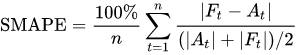

In [ ]:
# SMAPE: Error porcentual absoluto medio simétrico (MAPE ajustado)
def smape(preds, target):
    n = len(preds)
    masked_arr = ~((preds == 0) & (target == 0))
    preds, target = preds[masked_arr], target[masked_arr]
    num = np.abs(preds-target)
    denom = np.abs(preds)+np.abs(target)
    smape_val = (200*np.sum(num/denom))/n
    return smape_val

def lgbm_smape(y_true, y_pred):
    smape_val = smape(y_true, y_pred)
    return 'SMAPE', smape_val, False

## **Modelo LGMRegressor**
LGBMRegressor es un modelo basado en LightGBM (Light Gradient Boosting Machine), una implementación rápida y eficiente del algoritmo de boosting de árboles. Es particularmente útil para grandes conjuntos de datos y ha demostrado un rendimiento superior en muchas tareas de predicción.

El objetivo es encontrar un modelo 𝐹(𝑥) que minimice la pérdida entre las predicciones y los valores reales. Esto se logra mediante la adición de predictores de forma iterativa.

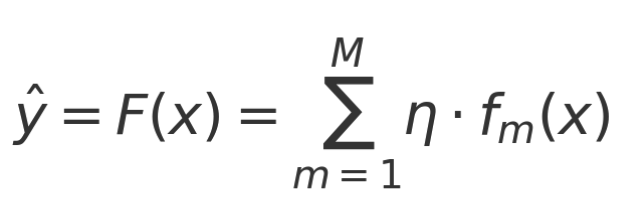


* y^:es la predicción final del modelo.
* 𝑀: es el número total de árboles.
* 𝜂: es la tasa de aprendizaje (learning rate).
* 𝑓𝑚(𝑥) es el 𝑚-ésimo árbol de decisión.
* 𝑥: es el conjunto de características de entrada.

In [ ]:
modelo_1 = lgb.LGBMRegressor(random_state=384,force_col_wise=True).fit(X_train, Y_train,
                                                      eval_metric= lambda y_true, y_pred: [lgbm_smape(y_true, y_pred)])

print("TRAIN SMAPE:", smape(Y_train, modelo_1.predict(X_train)))
print("VALID SMAPE:", smape(Y_val, modelo_1.predict(X_val)))

[LightGBM] [Info] Total Bins 17502
[LightGBM] [Info] Number of data points in the train set: 69320, number of used features: 100
[LightGBM] [Info] Start training from score 3.809680
TRAIN SMAPE: 3.597512202048384
VALID SMAPE: 3.560771449290972


## **Feature Importance**
La importancia de características es una métrica que indica qué variables son más relevantes para el modelo predictivo. En LightGBM, se puede observar qué variables aportan más al proceso de toma de decisiones del modelo, lo que ayuda a interpretar los resultados.

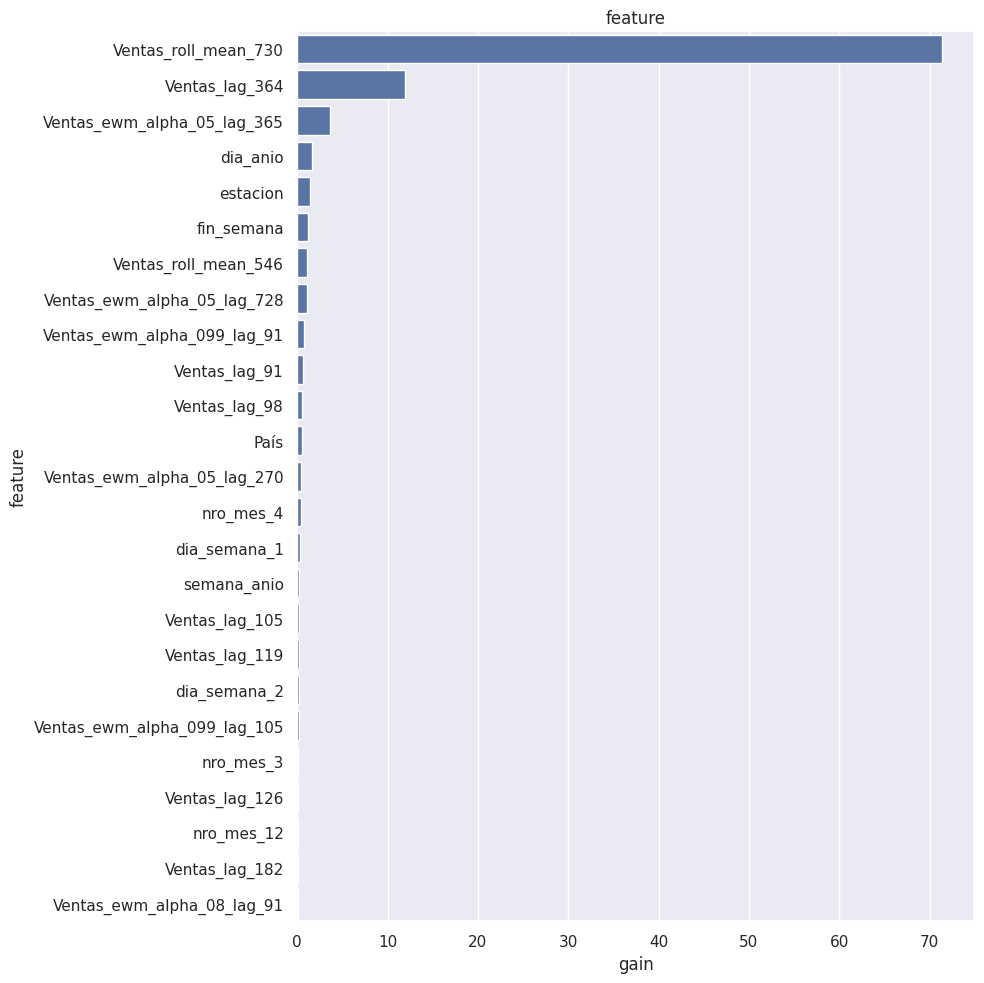

                          feature  split       gain
27           Ventas_roll_mean_730    131  71.344849
22                 Ventas_lag_364    270  11.978570
79    Ventas_ewm_alpha_05_lag_365     93   3.667225
4                        dia_anio    294   1.650980
14                       estacion     48   1.415778
6                      fin_semana     66   1.221784
26           Ventas_roll_mean_546     95   1.082307
81    Ventas_ewm_alpha_05_lag_728    121   1.033859
28    Ventas_ewm_alpha_099_lag_91     31   0.787085
15                  Ventas_lag_91     42   0.686317
16                  Ventas_lag_98     44   0.507227
1                            País    104   0.473093
78    Ventas_ewm_alpha_05_lag_270     55   0.439455
92                      nro_mes_4     23   0.368912
82                   dia_semana_1    110   0.310045
5                     semana_anio     44   0.206613
17                 Ventas_lag_105     28   0.170297
19                 Ventas_lag_119     91   0.159078
83          

In [ ]:
def plot_lgb_importances(model,plot=True,num=10):
    from matplotlib import pyplot as plt
    import seaborn as sns
    gain = model.booster_.feature_importance(importance_type='gain')
    feat_imp = pd.DataFrame({'feature': model.booster_.feature_name(),
                             'split': model.booster_.feature_importance(importance_type='split'),
                             'gain': 100 * gain / gain.sum()}).sort_values('gain', ascending=False)
    if plot:
        plt.figure(figsize=(10, 10))
        sns.set(font_scale=1)
        sns.barplot(x="gain", y="feature", data=feat_imp[0:25])
        plt.title('feature')
        plt.tight_layout()
        plt.show()
    else:
        print(feat_imp.head(num))
    print(feat_imp.head(num))

feature_imp_df = plot_lgb_importances(modelo_1, num=50)

## **Analisis del Error**
El análisis del error se enfoca en identificar y comprender las predicciones erróneas del modelo. Esto implica revisar las diferencias entre los valores predichos y los reales, buscando patrones que puedan indicar problemas en los datos o en el modelo.

In [ ]:
error = pd.DataFrame({
    "Fecha Pedido":val.Fecha_Pedido,
    "País":X_val.País,
    "Categoría Tarjeta":X_val.Categoría_Tarjeta,
    "actual":Y_val,
    "pred":modelo_1.predict(X_val)
}).reset_index(drop = True)

error["error"] = np.abs(error.actual-error.pred)

error.sort_values("error", ascending=False).head(10)

,Fecha Pedido,País,Categoría Tarjeta,actual,pred,error
3314,2023-12-22,5,1,1.945910,2.927065,0.981155
628,2023-10-16,5,4,2.302585,3.173472,0.870887
2592,2023-12-04,5,2,2.397895,3.257074,0.859179
2759,2023-12-08,6,1,1.945910,2.767683,0.821773
1188,2023-10-30,2,1,2.079442,2.878132,0.798691
1227,2023-10-31,6,3,2.302585,3.077990,0.775405
57,2023-10-02,6,4,2.197225,2.949475,0.752250
3309,2023-12-22,6,1,1.945910,2.680783,0.734873
339,2023-10-09,5,1,2.302585,3.029485,0.726900
3515,2023-12-27,6,1,1.945910,2.641168,0.695258


In [ ]:
error[["actual", "pred", "error"]].describe([0.7, 0.8, 0.9, 0.95, 0.99]).T

NameError: name 'error' is not defined

## **HiperParametros - Optimizacion del Modelo**
La optimización de hiperparámetros es el proceso de ajustar los parámetros del modelo (como la tasa de aprendizaje o el número de árboles en un algoritmo de boosting) para maximizar su rendimiento. Este proceso se realiza a menudo mediante técnicas de búsqueda en cuadrícula (grid search) o búsqueda aleatoria (random search).

In [ ]:
lgbm_params = {
"num_leaves":[20,31], # Default 31
"max_depth":[-1, 20, 30], # Default -1
"learning_rate":[0.1, 0.05], # Default 0.1
"n_estimators":[10000,15000], # Default 100
"min_split_gain":[0.0, 2,5], # Default 0
"min_child_samples":[10, 20, 30], # Default 20
"colsample_bytree":[0.5, 0.8, 1.0], # Default 1
"reg_alpha":[0.0, 0.5, 1], # Default 0
"reg_lambda":[0.0, 0.5, 1] # Default 0
}

In [127]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from lightgbm import early_stopping
import lightgbm as lgb

# --- Data Preparation Steps (replicated from previous cells to ensure consistency) ---
# 1. Load df_train (from cell pdQhiWeUlSBH)
url_train = "https://raw.githubusercontent.com/emadrigals104/PLFPython/main/Datasets/df_train.csv"
df = pd.read_csv(url_train, sep=',', header=0, parse_dates=['Fecha Pedido'])

# 2. Drop columns (from cell 6lKkJA9Opad1)
df = df.drop(columns=['ID Cliente', 'Nombre Cliente'])

# 3. Load df_test (from cell ypTgLEEUM-ap)
url_test = "https://raw.githubusercontent.com/emadrigals104/PLFPython/main/Datasets/df_test.csv"
df_test = pd.read_csv(url_test, sep=',', header=0, parse_dates=['Fecha Pedido'])

# 4. Concatenate df and df_test (from cell kxExR5XsNfzy)
df = pd.concat([df, df_test], sort=False)

# 5. Create date features (from cell 012LTrFEA8Dq)
def create_date_features(df):
    df['nro_mes'] = df['Fecha Pedido'].dt.month
    df['dia_mes'] = df['Fecha Pedido'].dt.day
    df['dia_anio'] = df['Fecha Pedido'].dt.dayofyear
    df['semana_anio'] = df['Fecha Pedido'].dt.isocalendar().week.astype(int) # Cast to int for consistency
    df['dia_semana'] = df['Fecha Pedido'].dt.dayofweek + 1
    df['anio'] = df['Fecha Pedido'].dt.year
    df["fin_semana"] = df['Fecha Pedido'].dt.weekday // 4
    df["trimestre"] = df['Fecha Pedido'].dt.quarter
    df['inicio_mes'] = df['Fecha Pedido'].dt.is_month_start.astype(int)
    df['fin_mes'] = df['Fecha Pedido'].dt.is_month_end.astype(int)
    df['inicio_trim'] = df['Fecha Pedido'].dt.is_quarter_start.astype(int)
    df['fin_trim'] = df['Fecha Pedido'].dt.is_quarter_end.astype(int)
    df['inicio_anio'] = df['Fecha Pedido'].dt.is_year_start.astype(int)
    df['fin_anio'] = df['Fecha Pedido'].dt.is_year_end.astype(int)
    df["estacion"] = np.where(df.nro_mes.isin([12,1,2,3,4]), 2, 1) # 1: Invierno - 2: Verano
    return df
df = create_date_features(df)

# 6. Label encode (from cell YpUczfHqmOIA)
# Define label encoders as global to be accessible for inverse_transform later if needed
global label_encoder_pais, label_encoder_categoria
label_encoder_pais = LabelEncoder()
label_encoder_categoria = LabelEncoder()
df['País'] = df['País'].astype(str) # Ensure string type before encoding
df['Categoría Tarjeta'] = df['Categoría Tarjeta'].astype(str) # Ensure string type before encoding
df['País'] = label_encoder_pais.fit_transform(df['País']) + 1
df['Categoría Tarjeta'] = label_encoder_categoria.fit_transform(df['Categoría Tarjeta']) + 1

# 7. Sort for feature creation (from cell c90w6OQ8Ckt5)
df.sort_values(by=['País', 'Categoría Tarjeta', 'Fecha Pedido'], axis=0, inplace=True)

# 8. Lag features (from cell c90w6OQ8Ckt5)
def random_noise(dataframe):
    return np.random.normal(size=(len(dataframe),))

def lag_features(dataframe, lags):
    for lag in lags:
        dataframe['Ventas_lag_' + str(lag)] = dataframe.groupby(["País", "Categoría Tarjeta"])['Ventas'].transform(
            lambda x: x.shift(lag)) + random_noise(dataframe)
    return dataframe
df = lag_features(df, [91, 98, 105, 112, 119, 126, 182, 364, 546, 728])

# 9. Rolling Mean features (from cell hflWLBZvDM85)
def roll_mean_features(dataframe, windows):
    for window in windows:
        dataframe['Ventas_roll_mean_' + str(window)] = dataframe.groupby(["País", "Categoría Tarjeta"])['Ventas']. \
                                                          transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=10, win_type="triang").mean()) + random_noise(
            dataframe)
    return dataframe
df = roll_mean_features(df, [365, 546, 730])

# 10. Exponentially Weighted Mean Features (from cell KHN0mfz-DkIp)
def ewm_features(dataframe, alphas, lags_ewm):
    dataframe = dataframe.copy()
    for alpha in alphas:
        for lag in lags_ewm:
            dataframe['Ventas_ewm_alpha_' + str(alpha).replace(".", "") + "_lag_" + str(lag)] = \
                dataframe.groupby(["País", "Categoría Tarjeta"])['Ventas']. \
                    transform(lambda x: x.shift(lag).ewm(alpha=alpha).mean())
    return dataframe
alphas = [0.99, 0.95, 0.9, 0.8, 0.7, 0.5]
lags_ewm = [91, 98, 105, 112, 180, 270, 365, 546, 728]
df = ewm_features(df, alphas, lags_ewm)

# 11. One-Hot Encoding and log1p (from cell 2K0ai5eeD9Ux)
if 'dia_semana' in df.columns and 'nro_mes' in df.columns:
    df = pd.get_dummies(df, columns=['dia_semana', 'nro_mes'], dtype=int)
else:
    print("Columns 'dia_semana' or 'nro_mes' not found for get_dummies, assuming already processed.")
df['Ventas'] = np.log1p(df["Ventas"].values)

# 12. Replace spaces in column names with underscores (from cell Dxy0UFZaVu1L)
df.columns = df.columns.str.replace(' ', '_')

# Ensure unique column labels after all transformations and renaming
df = df.loc[:, ~df.columns.duplicated(keep='first')]

# --- Train - Test - Split (from cell qtff3Pg7EaUC) ---
# The df object is now fully prepared.
df = df.sort_values("Fecha_Pedido").reset_index(drop=True)

# Train Validation Split
train = df.loc[(df["Fecha_Pedido"] < "2023-10-01"), :]
val = df.loc[(df["Fecha_Pedido"] >= "2023-10-01") & (df["Fecha_Pedido"] < "2024-01-01"), :]

# Define SMAPE (from cell eS1wZPb8FL7i) - necessary for eval_metric
def smape(preds, target):
    n = len(preds)
    masked_arr = ~((preds == 0) & (target == 0))
    preds, target = preds[masked_arr], target[masked_arr]
    num = np.abs(preds-target)
    denom = np.abs(preds)+np.abs(target)
    smape_val = (200*np.sum(num/denom))/n
    return smape_val

def lgbm_smape(y_true, y_pred):
    smape_val = smape(y_true, y_pred)
    return 'SMAPE', smape_val, False

cols = [col for col in train.columns if col not in ['Fecha_Pedido', 'id', 'Ventas', 'anio']]

Y_train = train['Ventas']
X_train = train[cols]

Y_val = val['Ventas']
X_val = val[cols]

# --- Model Training ---
# Ajustar el modelo con parada temprana usando callbacks
modelo_2 = lgb.LGBMRegressor(num_leaves=31, n_estimators=2000, max_depth=20, random_state=384, metric="custom")

modelo_2.fit(
    X_train[cols], Y_train,
    eval_set=[(X_val[cols], Y_val)],  # Conjunto de validación
    eval_metric=lambda y_true, y_pred: [lgbm_smape(y_true, y_pred)],
    callbacks=[early_stopping(stopping_rounds=100)]  # Callback para la parada temprana
)
print("Mejor Iteracion:", modelo_2.booster_.best_iteration)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.086145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17502
[LightGBM] [Info] Number of data points in the train set: 69320, number of used features: 100
[LightGBM] [Info] Start training from score 3.809680
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[416]	valid_0's SMAPE: 3.55186
Mejor Iteracion: 416


In [129]:
df.sort_values(["País", "Categoría_Tarjeta", "Fecha_Pedido"], inplace = True)

train_final = df.loc[(df["Fecha_Pedido"] < "2023-10-01"), :]
test_final = df.loc[(df["Fecha_Pedido"] >= "2023-10-01"), :]

# Re-defining 'cols' as it might be local to previous cells
cols = [col for col in df.columns if col not in ['Fecha_Pedido', 'id', 'Ventas', 'anio']]

X_train_final = train_final[cols]
Y_train_final = train_final.Ventas
X_test_final = test_final[cols]

final_model = lgb.LGBMRegressor(num_leaves=31, n_estimators=15000, max_depth=20, random_state=384, metric = "custom")
final_model.set_params(n_estimators=modelo_2.booster_.best_iteration)
final_model.fit(X_train_final[cols], Y_train_final,
                eval_metric= lambda y_true, y_pred: [lgbm_smape(y_true, y_pred)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17502
[LightGBM] [Info] Number of data points in the train set: 69320, number of used features: 100
[LightGBM] [Info] Start training from score 3.809680


LGBMRegressor(max_depth=20, metric='custom', n_estimators=416, random_state=384)

### **Invertir transformación**

In [149]:
temp_cat_train = pd.to_numeric(train_final['Categoría_Tarjeta'], errors='coerce')
train_final['Categoría_Tarjeta'] = label_encoder_categoria.inverse_transform((temp_cat_train.fillna(1).astype(int) - 1).clip(lower=0))

temp_cat_test = pd.to_numeric(test_final['Categoría_Tarjeta'], errors='coerce')
test_final['Categoría_Tarjeta'] = label_encoder_categoria.inverse_transform((temp_cat_test.fillna(1).astype(int) - 1).clip(lower=0))

In [148]:
temp_pais_train = pd.to_numeric(train_final['País'], errors='coerce')
train_final['País'] = label_encoder_pais.inverse_transform((temp_pais_train.fillna(1).astype(int) - 1).clip(lower=0))

temp_pais_test = pd.to_numeric(test_final['País'], errors='coerce')
test_final['País'] = label_encoder_pais.inverse_transform((temp_pais_test.fillna(1).astype(int) - 1).clip(lower=0))

## **5. ¿Cómo se comportan las predicciones y cómo podemos visualizarlas?**
**Propósito:** Generar y analizar las predicciones del modelo, visualizando los resultados de manera comprensible.
* **Preguntas relacionadas:**
1. ¿Cómo se comportan las predicciones en comparación con los datos reales?
2. ¿Qué podemos inferir al comparar las predicciones con la tendencia y la estacionalidad observadas?
3. ¿Cómo podemos visualizar las predicciones de manera clara para extraer conclusiones útiles?
* **Acciones en el EDA:**
1. Generar las predicciones utilizando el modelo final.
2. Guardar las predicciones y crear visualizaciones que comparen las predicciones con los datos reales, mostrando también las tendencias.
3. Usar gráficos para visualizar la tendencia, estacionalidad, y las predicciones de manera que faciliten su interpretación.

### **Generar las predicciones utilizando el modelo final**

In [162]:
# Generar las predicciones utilizando el modelo final
predicciones = final_model.predict(X_test_final)

# Crear un DataFrame para las predicciones y el train
train_final['Tipo'] = 'Train'
test_final['Pred'] = predicciones

# 'Fecha_Pedido' is already the index for train_final and test_final from previous steps.
# Commenting out the redundant set_index calls.
# train_final.set_index('Fecha_Pedido', inplace=True)
# test_final.set_index('Fecha_Pedido', inplace=True)

# Resamplear solo las columnas numéricas (por semana)
train_resampled = train_final[['Ventas']].resample('W').mean().reset_index()
test_resampled = test_final[['Pred']].resample('W').mean().reset_index()
test_resampled_real = test_final[['Ventas']].resample('W').mean().reset_index()

In [163]:
train_final.reset_index(inplace=True)
test_final.reset_index(inplace=True)

In [164]:
test_final.head()

,Fecha_Pedido,Categoría_Tarjeta,País,Ventas,id,...,nro_mes_9,nro_mes_10,nro_mes_11,nro_mes_12,Pred
0,2024-01-01,1,1,NaN,0.0,...,0,0,0,0,3.294542
1,2024-01-02,1,1,NaN,1.0,...,0,0,0,0,3.361979
2,2024-01-03,1,1,NaN,2.0,...,0,0,0,0,3.369116
3,2024-01-04,1,1,NaN,3.0,...,0,0,0,0,3.376871
4,2024-01-05,1,1,NaN,4.0,...,0,0,0,0,3.432038


In [168]:
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import pandas as pd # Ensure pandas is imported

# Make copies of train_final and test_final to avoid modifying global variables
train_final_plot = train_final.copy()
test_final_plot = test_final.copy()

# Generate predictions using the final model (assuming final_model and X_test_final are globally available)
predicciones = final_model.predict(X_test_final)

# Create a DataFrame for predictions and training data (modifying copies)
train_final_plot['Tipo'] = 'Train'
test_final_plot['Pred'] = predicciones

# Configure 'Fecha_Pedido' as index for resampling
train_final_plot.set_index('Fecha_Pedido', inplace=True)
test_final_plot.set_index('Fecha_Pedido', inplace=True)

# Resample numeric columns (by week)
train_resampled = train_final_plot[['Ventas']].resample('W').mean().reset_index()
test_resampled = test_final_plot[['Pred']].resample('W').mean().reset_index()
# test_resampled_real is not used in this plot, so omitting for brevity.

# Crear la figura con Plotly
fig = make_subplots()

# Línea de Train
fig.add_trace(go.Scatter(
    x=train_resampled['Fecha_Pedido'],
    y=train_resampled['Ventas'],
    mode='lines',
    name='Train',
    line=dict(color='green', width=2, dash='solid')
))

# Línea de Predicciones
fig.add_trace(go.Scatter(
    x=test_resampled['Fecha_Pedido'],
    y=test_resampled['Pred'],
    mode='lines',
    name='Pred',
    line=dict(color='blue', width=2, dash='solid')
))

# Añadir título y etiquetas a los ejes
fig.update_layout(
    title='Train vs Predicciones',
    xaxis_title='Fecha Pedido',
    yaxis_title='Ventas',
    template='plotly_white',
    width=900,
    height=500
)

# Mostrar la figura
fig.show()

## **Guardar la Prediccion**

In [173]:
test_preds = final_model.predict(X_test_final)

# Create a temporary DataFrame to hold relevant test_final columns and predictions
temp_test_df = test_final.copy()
temp_test_df['predicted_Ventas_log1p'] = test_preds

# Identify the rows that correspond to the actual future test period
# These are the rows where the original 'Ventas' column was NaN.
# After log1p transformation, these still remain NaN.
submission_df_rows = temp_test_df[temp_test_df['Ventas'].isna()]

# Create the submission DataFrame
submission = pd.DataFrame({
    "id": submission_df_rows.id.astype(int), # Now 'id' column should not have NaNs
    "Ventas": np.expm1(submission_df_rows.predicted_Ventas_log1p)
})

submission.to_csv("submission.csv", index=None)

submission.head()

,id,Ventas
0,0,25.965059
1,1,27.846235
2,2,28.052831
3,3,28.279014
4,4,29.939649


In [177]:
import pandas as pd

forecast = pd.DataFrame({
    "Fecha Pedido":test_final["Fecha_Pedido"],
    "País":test_final["País"],
    "Categoría Tarjeta":test_final["Categoría_Tarjeta"],
    "Ventas":np.expm1(test_preds)
})

forecast.head()

,Fecha Pedido,País,Categoría Tarjeta,Ventas
0,2024-01-01,1,1,25.965059
1,2024-01-02,1,1,27.846235
2,2024-01-03,1,1,28.052831
3,2024-01-04,1,1,28.279014
4,2024-01-05,1,1,29.939649


# **Visualización de Predicciones**

In [179]:
# Convertir las columnas a cadenas y crear la columna combinada 'Pais-Tarjeta'
forecast['País'] = forecast['País'].astype(str)
forecast['Categoría Tarjeta'] = forecast['Categoría Tarjeta'].astype(str)
forecast['Pais-Tarjeta'] = forecast['País'] + '_' + forecast['Categoría Tarjeta']

# Pivotear los datos y hacer resample para obtener la media semanal
ventas = forecast.pivot_table(index='Fecha Pedido', columns='Pais-Tarjeta', values='Ventas', aggfunc='mean').resample('D').mean()
forecast.drop(columns=['Pais-Tarjeta'], inplace=True)

# Resetear el índice para que 'Fecha Pedido' sea una columna
ventas = ventas.reset_index()

# Obtener listas únicas de países y categorías de tarjetas
paises = forecast['País'].unique().tolist()
categorias_tarjeta = forecast['Categoría Tarjeta'].unique().tolist()

In [185]:
# Selecciones iniciales
pais = paises[0]
categoria = categorias_tarjeta[0]

i = pais + '_' + categoria

# Preparar la fuente de datos
fuente_ventas = pd.DataFrame({
    'Fecha Pedido': ventas['Fecha Pedido'],
    'y': ventas[i].values if i in ventas.columns else [0]*len(ventas)
})
source = ColumnDataSource(data=fuente_ventas)

# Preparar la fuente de datos de referencia
datos_ref = ventas.copy()
ref = ColumnDataSource(data=datos_ref)

# Crear la figura
p = figure(width=750, height=300, title=i, x_axis_type='datetime', tools="pan,wheel_zoom,reset")
linea = p.line(x='Fecha Pedido', y='y', source=source, color='blue', legend_label='Ventas')

# Añadir tooltips
tooltips = [
    ('Fecha Pedido', '@{Fecha Pedido}{%F}'),
    ('Ventas', '@y'),
]

hover = HoverTool(
    tooltips=tooltips,
    formatters={'@{Fecha Pedido}': 'datetime'},
    mode='vline',
    renderers=[linea]
)
p.add_tools(hover)

# Crear widgets de selección
select_pais = Select(title="País", value=pais, options=paises)
select_categoria = Select(title="Categoría Tarjeta", value=categoria, options=categorias_tarjeta)

# Definir la callback
callback = CustomJS(
    args=dict(source=source, ref=ref, country_select=select_pais, category_select=select_categoria, p=p),
    code="""
    var pais = country_select.value;
    var categoria = category_select.value;
    var nombre_columna = pais + '_' + categoria;

    var datos = ref.data;
    var y_nueva = datos[nombre_columna];
    if (y_nueva === undefined) {
        y_nueva = Array(source.data['y'].length).fill(0);
    }

    source.data['y'] = y_nueva;
    p.title.text = nombre_columna;
    source.change.emit();
"""
)

# Conectar las callbacks a los widgets
select_pais.js_on_change('value', callback)
select_categoria.js_on_change('value', callback)

# Organizar el layout
layout = column(
    Div(text='<h4>Reporte de Ventas (Bokeh)</h4>'),
    row(select_pais, select_categoria),
    p
)

show(layout)